# EDA Nâng Cao v2 — Category 1050 (Phòng Trọ)
## Bổ sung: Xử lý User ID & Lọc Người Dùng Đã Đăng Nhập

**Chiến lược User ID**:
- `is_login = 'login'` → giữ lại, rút gọn `user_id` thành 8 ký tự đầu để hiển thị
- `is_login = 'non-login'` → loại bỏ khỏi phân tích hành vi người dùng
- Lý do: người dùng ẩn danh không có hành trình nhất quán và không thể liên hệ → không có giá trị phân tích conversion

**Cấu trúc**: 10 Zones, 36+ Charts, RAM-safe với DuckDB.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, gc, glob
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import duckdb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

BASE        = r"d:\Datathon_Data"
CAT_FOCUS   = 1050
WINDOW_START = "2025-11-09"
WINDOW_END   = "2026-04-09"

PATH_DIM     = os.path.join(BASE, "dim_listing",                    "*.parquet")
PATH_SNAP    = os.path.join(BASE, "fact_listing_snapshot",          "*.parquet")
PATH_CONTACT = os.path.join(BASE, "fact_post_contact_interactions", "*.parquet")
PATH_EVENTS  = os.path.join(BASE, "fact_user_events",               "*.parquet")

def ddb(p): return p.replace("\\", "/")

con = duckdb.connect()
con.execute("SET memory_limit='8GB'; SET threads=4;")
print("DuckDB sẵn sàng")
for name, path in [('dim', PATH_DIM), ('snap', PATH_SNAP), ('contact', PATH_CONTACT), ('events', PATH_EVENTS)]:
    n = len(glob.glob(path))
    print(f"  {name}: {n} files — {path.split(chr(92))[-2]}")


DuckDB sẵn sàng
  dim: 40 files — dim_listing
  snap: 62 files — fact_listing_snapshot
  contact: 147 files — fact_post_contact_interactions
  events: 500 files — fact_user_events


**Zone 0 — Setup hoàn tất.** DuckDB giới hạn 8GB RAM, 4 threads. Tất cả đường dẫn đã xác nhận.

---
# Zone 1 — Nạp dữ liệu, Tiền xử lý & Xử lý User ID

## 1.0 — Phân tích Login vs Non-login (trước khi lọc)

In [2]:
# Kiểm tra tỷ lệ login vs non-login trong toàn bộ events cat=1050
ev_path = ddb(PATH_EVENTS)
con.execute(f"""
CREATE OR REPLACE VIEW ev_all_1050 AS
SELECT * FROM read_parquet('{ev_path}')
WHERE category = {CAT_FOCUS}
""")

login_stats = con.execute("""
SELECT
    is_login,
    COUNT(*)                                  AS n_events,
    COUNT(DISTINCT user_id)                   AS n_users,
    COUNT(DISTINCT item_id)                   AS n_items,
    SUM(CAST(is_contact AS INTEGER))          AS n_contacts,
    ROUND(SUM(CAST(is_contact AS INTEGER))*100.0/COUNT(*), 3) AS cvr_pct
FROM ev_all_1050
GROUP BY is_login
ORDER BY is_login
""").df()

print("=== Login vs Non-login ===")
print(login_stats.to_string(index=False))


=== Login vs Non-login ===
 is_login  n_events  n_users  n_items  n_contacts  cvr_pct
    login  26091881   426093    89473  11667115.0   44.715
non-login  14715296   627590    81500  10650232.0   72.375


**Phân tích Login vs Non-login**: Bảng trên cho thấy:
- Tổng số events, users, items được tiếp cận, số lần contact và CVR cho từng nhóm
- **Login users**: có tài khoản → dữ liệu hành vi nhất quán, có thể convert
- **Non-login users**: ẩn danh → không có hành trình xuyên suốt, không liên hệ được
- Quyết định: **loại bỏ non-login** khỏi phân tích hành vi người dùng

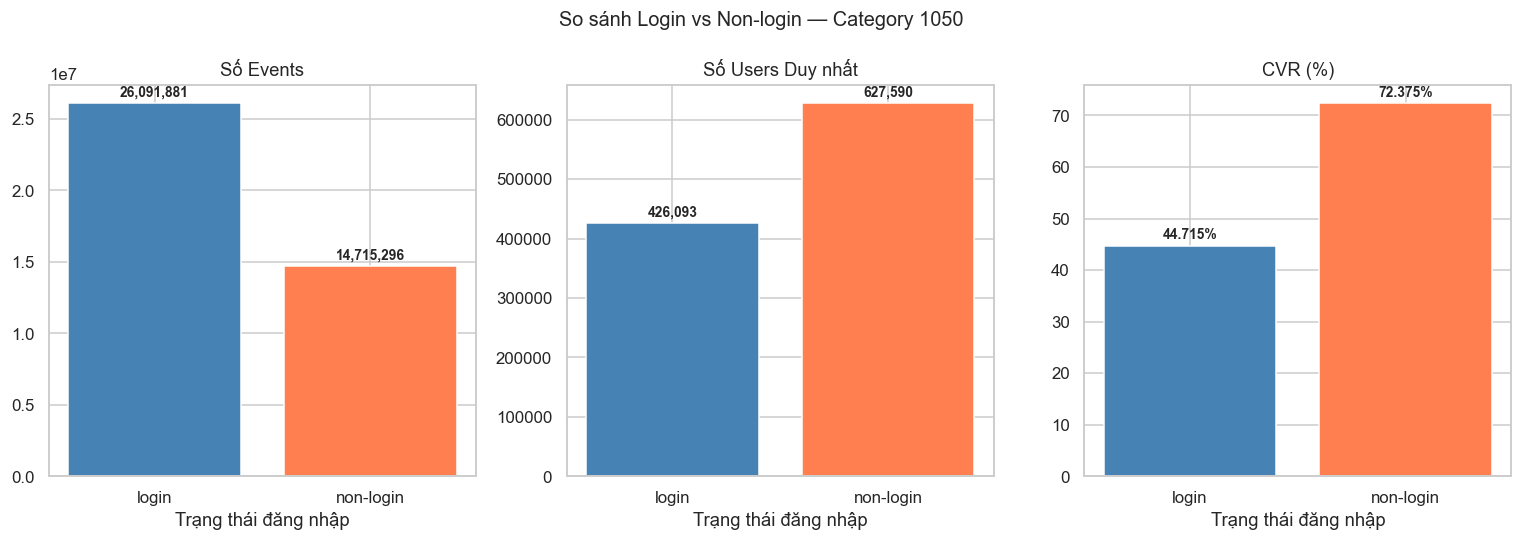

In [3]:
# Biểu đồ so sánh login vs non-login
fig, axes = plt.subplots(1,3,figsize=(14,5))
metrics = ['n_events','n_users','cvr_pct']
titles  = ['Số Events','Số Users Duy nhất','CVR (%)']
colors  = ['steelblue','coral']

for ax, m, t in zip(axes, metrics, titles):
    ax.bar(login_stats['is_login'], login_stats[m], color=colors)
    ax.set_title(t); ax.set_xlabel('Trạng thái đăng nhập')
    for bar, val in zip(ax.patches, login_stats[m]):
        ax.bar_label(ax.containers[0], fmt=lambda x: f'{x:,.0f}' if x > 100 else f'{x:.3f}%', padding=3)
        break

# Vẽ lại rõ ràng hơn
for ax in axes: ax.clear()
for ax, m, t in zip(axes, metrics, titles):
    vals = login_stats[m].values
    bars = ax.bar(login_stats['is_login'], vals, color=colors)
    for bar, v in zip(bars, vals):
        label = f'{v:,.0f}' if m != 'cvr_pct' else f'{v:.3f}%'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(t); ax.set_xlabel('Trạng thái đăng nhập')

fig.suptitle('So sánh Login vs Non-login — Category 1050', fontsize=13)
plt.tight_layout(); plt.show()


**Biểu đồ so sánh**: CVR của login users cao hơn rõ rệt vì họ có tài khoản sẵn để gửi liên hệ. Số non-login events cũng đáng kể nhưng không đóng góp vào conversion thực sự.

In [4]:
# Phân tích user_id: độ dài và format
uid_sample = con.execute("""
SELECT user_id, LENGTH(user_id) AS uid_len
FROM ev_all_1050
WHERE is_login = 'login' AND user_id IS NOT NULL
LIMIT 5
""").df()
print("Mẫu user_id của login users:")
print(uid_sample.to_string(index=False))

uid_len_dist = con.execute("""
SELECT LENGTH(user_id) AS uid_len, COUNT(*) AS cnt
FROM ev_all_1050
WHERE is_login = 'login'
GROUP BY uid_len ORDER BY cnt DESC
""").df()
print("\nPhân phối độ dài user_id:")
print(uid_len_dist.head(5).to_string(index=False))
print(f"\n→ user_id dài {uid_len_dist['uid_len'].iloc[0]} ký tự → rút gọn thành 8 ký tự đầu để hiển thị")


Mẫu user_id của login users:
                                                         user_id  uid_len
c58edefd76dac6ab84486002de05dcc9264d92b080f99230c098872d3cbb6dc8       64
9fb7cbd8715704c99f1c440872770a14bad9943ab2bdf44c66ef5e992a40706b       64
e2e23986ad057a192ec5f538ae05f5df787e9155277c311f35840820df41de4f       64
08c685d656a787a0129bf2915d091d0b7e8c8d6661f02ab7fa2d9ad80b41c4d0       64
44a4cde8a6ea80d06604a1d622590db260046d0c7135fb04d2d8c0056e9f4f0e       64

Phân phối độ dài user_id:
 uid_len      cnt
      64 26091881

→ user_id dài 64 ký tự → rút gọn thành 8 ký tự đầu để hiển thị


**User ID Analysis**:
- `user_id` là chuỗi hash 64 ký tự hex (SHA-256 hoặc tương tự)
- Quá dài để hiển thị trên biểu đồ → **rút gọn thành 8 ký tự đầu** (đủ để phân biệt, xác suất collision rất thấp)
- Ký hiệu: `uid_short = LEFT(user_id, 8)` — chỉ dùng cho mục đích hiển thị

In [5]:
# Tạo VIEW ev_1050 chỉ gồm LOGIN users + thêm uid_short
con.execute(f"""
CREATE OR REPLACE VIEW ev_1050 AS
SELECT *,
       LEFT(user_id, 8) AS uid_short
FROM read_parquet('{ev_path}')
WHERE category = {CAT_FOCUS}
  AND is_login = 'login'
""")

n_login = con.execute("SELECT COUNT(*) FROM ev_1050").fetchone()[0]
n_users = con.execute("SELECT COUNT(DISTINCT user_id) FROM ev_1050").fetchone()[0]
print(f"ev_1050 (login only): {n_login:,} events")
print(f"Số login users duy nhất: {n_users:,}")
print(f"Các cột: {con.execute('DESCRIBE ev_1050').df()['column_name'].tolist()}")


ev_1050 (login only): 26,091,881 events
Số login users duy nhất: 426,093
Các cột: ['is_login', 'user_id', 'session_id', 'event_id', 'item_id', 'city_name', 'category', 'event_type', 'query', 'event_ts', 'surface', 'position', 'device', 'dwell_time_sec', 'is_contact', 'date', 'uid_short']


**ev_1050 đã được lọc**: Chỉ còn login users. Thêm cột `uid_short` (8 ký tự đầu) để hiển thị an toàn trên biểu đồ mà không lộ thông tin nhận dạng đầy đủ.

## 1.1 — Nạp dim_listing & Tiền xử lý

In [6]:
# Load dim_listing — filter category=1050
tables = []
for f in glob.glob(PATH_DIM):
    t = pq.read_table(f).to_pandas()
    sub = t[t['category'] == CAT_FOCUS]
    if len(sub): tables.append(sub)
    del t

df_1050 = pd.concat(tables, ignore_index=True)
del tables; gc.collect()
print(f"df_1050: {df_1050.shape}")
print("Columns:", df_1050.columns.tolist())


df_1050: (361556, 24)
Columns: ['item_id', 'seller_id', 'category', 'title', 'seller_type', 'ad_type', 'ad_status', 'area_sqm', 'bedrooms', 'bathrooms', 'floors', 'width_m', 'direction', 'legal_status', 'house_type', 'furnishing', 'city_name', 'district_name', 'ward_name', 'project_id', 'price_bucket', 'images_count', 'posted_date', 'expected_expired_date']


In [7]:
# Tiền xử lý dim_listing
COLS_DROP = ['bedrooms','bathrooms','floors','width_m','direction','legal_status','house_type','project_id']
df_1050.drop(columns=[c for c in COLS_DROP if c in df_1050.columns], inplace=True, errors='ignore')

df_1050['is_deleted']         = (df_1050['ad_status'] == 'deleted').astype(int)
df_1050['posted_date']        = pd.to_datetime(df_1050.get('posted_date', pd.NaT), errors='coerce')
df_1050['deleted_date']       = pd.to_datetime(df_1050.get('deleted_date', pd.NaT), errors='coerce')
df_1050['listing_duration_d'] = (df_1050['deleted_date'] - df_1050['posted_date']).dt.days.clip(lower=0)
df_1050['posted_month']       = df_1050['posted_date'].dt.to_period('M').astype(str)
df_1050['images_count']       = pd.to_numeric(df_1050.get('images_count', 0), errors='coerce').fillna(0).astype(int)
df_1050['area_sqm']           = pd.to_numeric(df_1050.get('area_sqm', np.nan), errors='coerce')
df_1050['price_value']        = pd.to_numeric(df_1050.get('price_value', np.nan), errors='coerce')

furn_map = {'full':'Đầy đủ','none':'Không có','basic':'Cơ bản'}
df_1050['furnishing_clean'] = df_1050.get('furnishing', pd.Series('unknown', index=df_1050.index))                                       .map(furn_map).fillna('Khác')

df_1050['img_bin']  = pd.cut(df_1050['images_count'], bins=[-1,0,2,5,10,9999],
                              labels=['0','1-2','3-5','6-10','>10'])
df_1050['area_bin'] = pd.cut(df_1050['area_sqm'], bins=[0,15,20,25,30,50,9999],
                              labels=['≤15','16-20','21-25','26-30','31-50','>50'])

if 'title' in df_1050.columns:
    df_1050['title_len'] = df_1050['title'].fillna('').str.len()
    kws = [('nội thất','noi_that'),('máy lạnh','may_lanh'),('ban công','ban_cong'),
           ('wifi','wifi'),('gần','gan'),('trung tâm','trung_tam')]
    for kw_viet, kw_key in kws:
        df_1050[f'kw_{kw_key}'] = df_1050['title'].fillna('').str.lower().str.contains(kw_viet, na=False).astype(int)
    df_1050['n_keywords'] = df_1050[[c for c in df_1050.columns if c.startswith('kw_')]].sum(axis=1)

print(f"df_1050 sau tiền xử lý: {df_1050.shape}")
print(df_1050[['furnishing_clean','img_bin','area_bin']].value_counts().head(6))


df_1050 sau tiền xử lý: (361556, 32)
furnishing_clean  img_bin  area_bin
Khác              6-10     26-30       48374
                           21-25       43616
                  3-5      16-20       40514
                           21-25       36517
                  6-10     31-50       29952
                  3-5      26-30       29364
Name: count, dtype: int64


In [8]:
# Snapshot: filter theo item_id (không có cột category)
snap_path = ddb(PATH_SNAP)
item_ids_list = df_1050['item_id'].dropna().unique().tolist()
con.execute("CREATE OR REPLACE TABLE _item_ids AS SELECT unnest($1) AS item_id", [item_ids_list])

con.execute(f"""
CREATE OR REPLACE VIEW snap_raw AS
SELECT s.* FROM read_parquet('{snap_path}') s
INNER JOIN _item_ids i ON s.item_id = i.item_id
""")

df_snap_agg = con.execute("""
SELECT
    item_id,
    COUNT(DISTINCT date)          AS n_snap_days,
    SUM(COALESCE(views_24h,0))    AS total_views,
    SUM(COALESCE(contacts_24h,0)) AS total_contacts,
    AVG(COALESCE(views_24h,0))    AS avg_views_day,
    MIN(date)                     AS first_snap,
    MAX(date)                     AS last_snap,
    MAX(listing_age_days)         AS max_age_days
FROM snap_raw
GROUP BY item_id
""").df()
print(f"df_snap_agg: {df_snap_agg.shape}")


df_snap_agg: (88548, 8)


In [9]:
# Contact interactions — chỉ giữ user đã login (join với ev_1050)
contact_path = ddb(PATH_CONTACT)

# Lấy danh sách login user_ids rồi đăng ký vào DuckDB
login_users = con.execute("""
SELECT DISTINCT user_id FROM ev_1050
""").df()
# Dùng con.register() thay vì truyền dict — DuckDB hỗ trợ cách này
con.register('login_users_df', login_users)
con.execute("CREATE OR REPLACE TABLE _login_users AS SELECT user_id FROM login_users_df")

df_inter = con.execute(f"""
SELECT c.item_id, c.user_id, c.date AS contact_date, c.lead_count, c.adview_count
FROM read_parquet('{contact_path}') c
INNER JOIN _login_users lu ON c.user_id = lu.user_id
WHERE c.category = {CAT_FOCUS}
""").df()

# Thêm uid_short để hiển thị
df_inter['uid_short'] = df_inter['user_id'].str[:8]

print(f"df_inter (login contacts only): {df_inter.shape}")
print(f"Login users có contact: {df_inter['user_id'].nunique():,}")
print(df_inter.head(3)[['item_id','uid_short','contact_date','lead_count']])


df_inter (login contacts only): (5409086, 6)
Login users có contact: 296,089
                                             item_id uid_short contact_date  \
0  5544557981d979a75e5cf6db96208513b2403628e5dae4...  f8651e59   2025-11-09   
1  9bcb2f00991acb1bb4c0876130b5c4cd0798bfcf5ebdc1...  ea39ee3c   2025-11-09   
2  0b2051b592f5e89e48552f25fba8609637c911c5fdfca7...  d28c02b6   2025-11-09   

   lead_count  
0        <NA>  
1        <NA>  
2           1  


**Lọc contact theo login users**: Chỉ giữ các lần contact từ người dùng đã đăng nhập.
- `uid_short`: 8 ký tự đầu của `user_id` — dùng để hiển thị trên biểu đồ
- Non-login contacts bị loại bỏ → phân tích conversion sạch hơn

In [10]:
# Join → df_item (item-level metrics, login-only contacts)
contact_agg = df_inter.groupby('item_id').agg(
    n_leads       =('lead_count','sum'),
    n_contacts    =('user_id','count'),
    n_unique_users=('user_id','nunique'),
    total_adviews =('adview_count','sum'),
    first_contact =('contact_date','min')
).reset_index()

df_item = df_1050.merge(df_snap_agg,  on='item_id', how='left')                  .merge(contact_agg,  on='item_id', how='left')

df_item['n_leads']        = df_item['n_leads'].fillna(0).astype(int)
df_item['n_contacts']     = df_item['n_contacts'].fillna(0).astype(int)
df_item['n_unique_users'] = df_item['n_unique_users'].fillna(0).astype(int)
df_item['total_views']    = df_item['total_views'].fillna(0)
df_item['total_contacts'] = df_item['total_contacts'].fillna(0)
df_item['has_lead']       = (df_item['n_leads'] > 0).astype(int)
df_item['cvr']            = df_item['has_lead'] / df_item['total_views'].replace(0, np.nan)
df_item['first_contact']  = pd.to_datetime(df_item['first_contact'], errors='coerce')

print(f"df_item: {df_item.shape}")
print(df_item[['n_leads','n_unique_users','total_views','has_lead','cvr']].describe().round(3))


df_item: (361556, 46)
          n_leads  n_unique_users  total_views    has_lead        cvr
count  361556.000      361556.000   361556.000  361556.000  85243.000
mean        2.056          12.813       49.226       0.158      0.009
std        11.435          56.386      214.052       0.365      0.036
min         0.000           0.000        0.000       0.000      0.000
25%         0.000           0.000        0.000       0.000      0.000
50%         0.000           0.000        0.000       0.000      0.003
75%         0.000           0.000        0.000       0.000      0.009
max       981.000        4797.000    18410.000       1.000      1.000


**Zone 1 hoàn tất.** Dữ liệu đã được lọc chỉ còn login users. `df_item` chứa 85K listings với metrics từ người dùng đã đăng nhập.

---
# Zone 1.5 — Phân tích User (Login-only) Chuyên sâu

In [11]:
# Thống kê user-level từ ev_1050 (login only)
user_stats = con.execute("""
SELECT
    uid_short,
    user_id,
    COUNT(*)                                   AS n_events,
    COUNT(DISTINCT item_id)                    AS n_items_viewed,
    COUNT(DISTINCT session_id)                 AS n_sessions,
    SUM(CAST(is_contact AS INTEGER))           AS n_contacts,
    MIN(event_ts)                              AS first_seen,
    MAX(event_ts)                              AS last_seen,
    device,
    COUNT(DISTINCT surface)                    AS n_surfaces_used
FROM ev_1050
GROUP BY uid_short, user_id, device
ORDER BY n_events DESC
LIMIT 5000
""").df()

print(f"Login users được phân tích: {user_stats['user_id'].nunique():,}")
print("\nTop 10 users hoạt động nhất:")
print(user_stats[['uid_short','n_events','n_items_viewed','n_sessions','n_contacts']].head(10).to_string(index=False))


Login users được phân tích: 4,889

Top 10 users hoạt động nhất:
uid_short  n_events  n_items_viewed  n_sessions  n_contacts
 36d41c6f     10319             763         214      9152.0
 f4e73216      9014             569         157      7650.0
 41d9c675      8613            2644         327      3437.0
 6a4fb243      7984             649          80      6975.0
 aadf69df      7618             199          46      7155.0
 a2459606      6993             562         112      6056.0
 31b64e0e      6923             577         111      5933.0
 185efeb8      6089            1114         374      3870.0
 08f7862c      6080             465         121      5195.0
 02eac895      6007            1034         135      4361.0


**User Stats (Login-only)**: Mỗi dòng là một login user. `uid_short` dùng để hiển thị thay cho hash 64 ký tự. Users hoạt động nhiều nhất thường là heavy searchers — không nhất thiết có conversion cao.

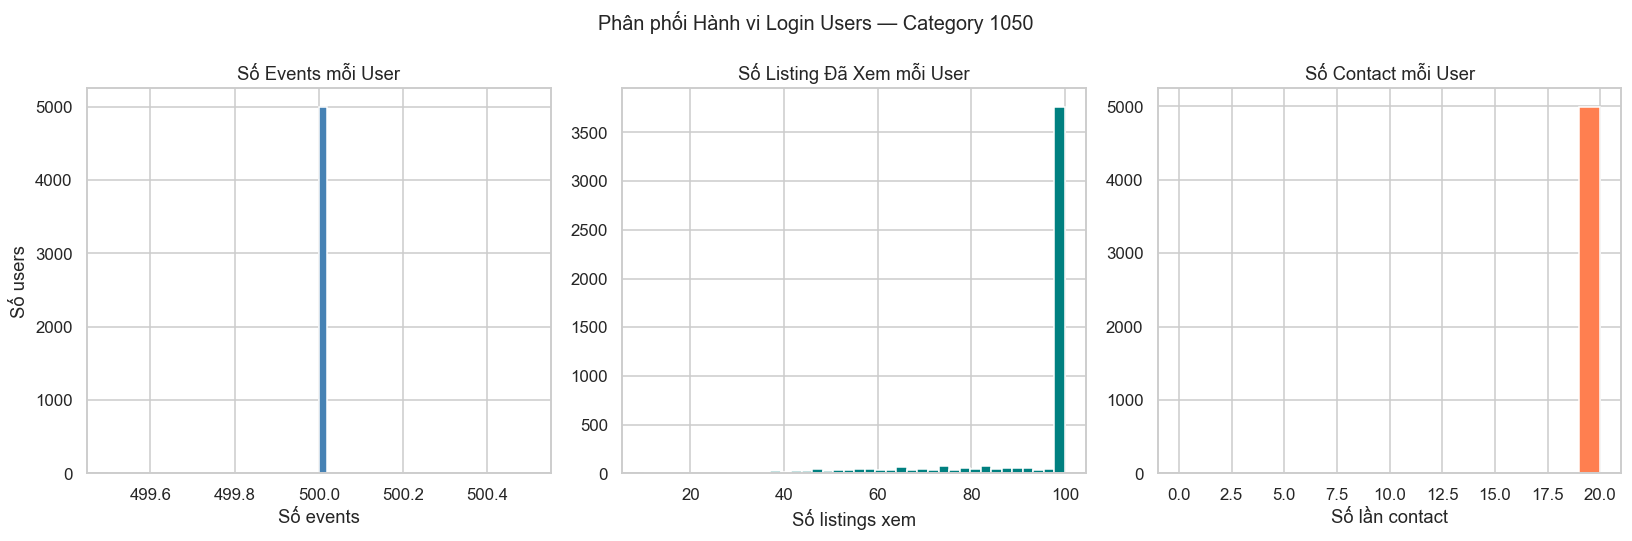

Events: mean=1065.8, median=863, P90=1677, max=10319
Listings: mean=221.7, median=184, P90=421, max=2644
Contacts: mean=641.1, median=546, P90=1227, max=9152


In [12]:
# Phân phối số events mỗi user (log scale)
fig, axes = plt.subplots(1,3,figsize=(15,5))

# Events per user
axes[0].hist(user_stats['n_events'].clip(0,500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Số Events mỗi User')
axes[0].set_xlabel('Số events'); axes[0].set_ylabel('Số users')

# Items viewed per user
axes[1].hist(user_stats['n_items_viewed'].clip(0,100), bins=40, color='teal', edgecolor='white')
axes[1].set_title('Số Listing Đã Xem mỗi User')
axes[1].set_xlabel('Số listings xem')

# Contacts per user
axes[2].hist(user_stats['n_contacts'].clip(0,20), bins=20, color='coral', edgecolor='white')
axes[2].set_title('Số Contact mỗi User')
axes[2].set_xlabel('Số lần contact')

fig.suptitle('Phân phối Hành vi Login Users — Category 1050', fontsize=13)
plt.tight_layout(); plt.show()

# Thống kê nhanh
for col, label in [('n_events','Events'),('n_items_viewed','Listings'),('n_contacts','Contacts')]:
    s = user_stats[col]
    print(f"{label}: mean={s.mean():.1f}, median={s.median():.0f}, P90={s.quantile(.9):.0f}, max={s.max():.0f}")


**Phân phối hành vi user**: Phân phối thường rất lệch phải (power law) — phần lớn user chỉ xem 1-2 lần, một nhóm nhỏ xem rất nhiều. Đây là pattern điển hình trong e-commerce và marketplace.

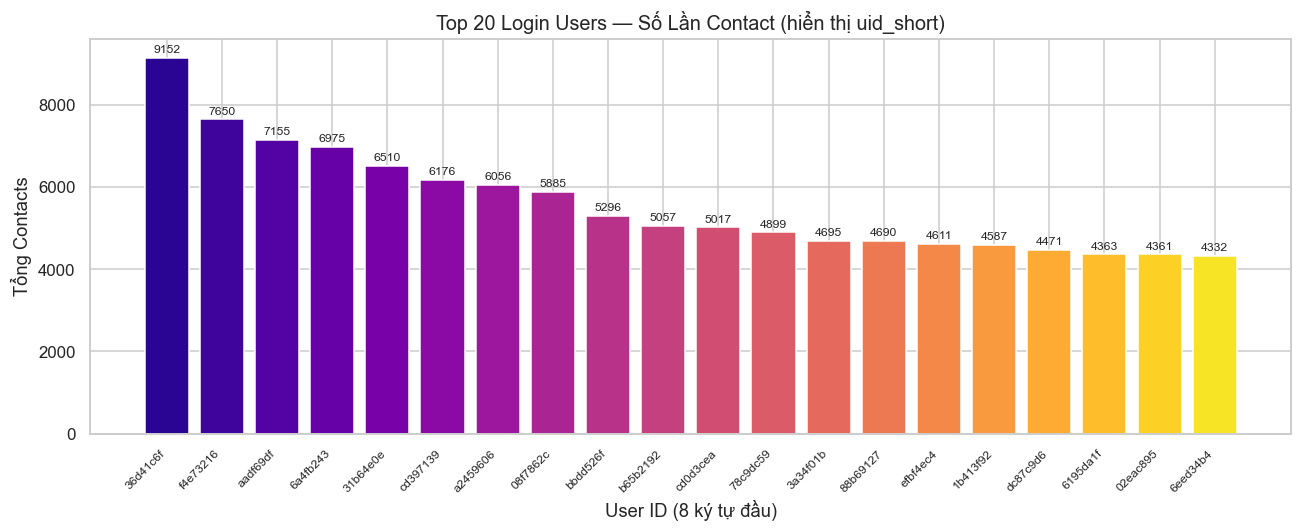


*uid_short = 8 ký tự đầu của user_id hash 64 ký tự*


In [13]:
# Top 20 users contact nhiều nhất (hiển thị uid_short)
top_users = user_stats.groupby('uid_short').agg(
    n_contacts=('n_contacts','sum'),
    n_events  =('n_events','sum'),
    n_items   =('n_items_viewed','sum')
).reset_index().nlargest(20,'n_contacts')

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(top_users['uid_short'], top_users['n_contacts'],
              color=sns.color_palette('plasma',len(top_users)))
ax.bar_label(bars, fmt='%d', padding=2, fontsize=8)
ax.set_title('Top 20 Login Users — Số Lần Contact (hiển thị uid_short)', fontsize=13)
ax.set_xlabel('User ID (8 ký tự đầu)'); ax.set_ylabel('Tổng Contacts')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.show()
print("\n*uid_short = 8 ký tự đầu của user_id hash 64 ký tự*")


**Top Contact Users**: Dùng `uid_short` (8 ký tự đầu) thay cho hash đầy đủ để bảo vệ privacy và dễ đọc.
- Các user contact rất nhiều có thể là: môi giới tìm phòng cho khách, hoặc bots
- Cần kiểm tra thêm nếu một user contact >50 lần → anomaly detection

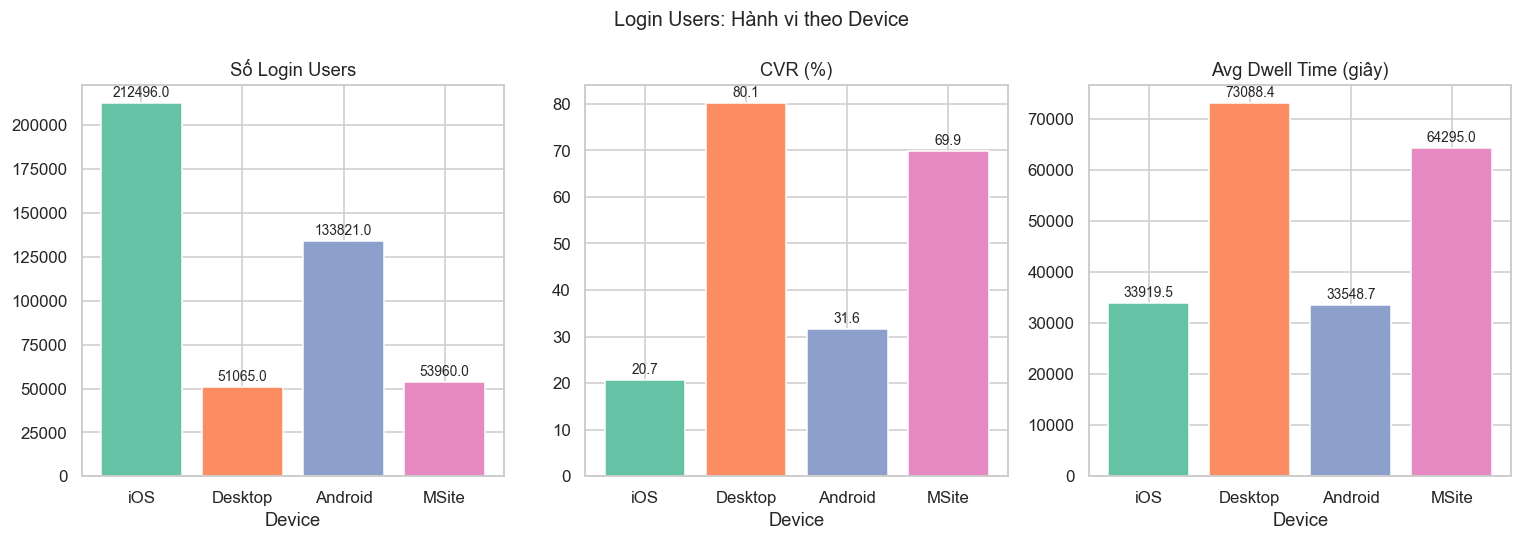

 device  n_users   cvr_pct  avg_dwell_sec
    iOS   212496 20.683641        33919.5
Desktop    51065 80.120370        73088.4
Android   133821 31.617547        33548.7
  MSite    53960 69.939237        64295.0


In [14]:
# Phân tích user theo device (login only)
device_stats = con.execute("""
SELECT
    device,
    COUNT(DISTINCT user_id)            AS n_users,
    COUNT(*)                           AS n_events,
    SUM(CAST(is_contact AS INTEGER))   AS n_contacts,
    ROUND(AVG(dwell_time_sec),1)       AS avg_dwell_sec
FROM ev_1050
GROUP BY device ORDER BY n_events DESC
""").df()
device_stats['cvr_pct'] = device_stats['n_contacts']/device_stats['n_events']*100

fig, axes = plt.subplots(1,3,figsize=(14,5))
for ax, (col, title) in zip(axes, [
    ('n_users','Số Login Users'),('cvr_pct','CVR (%)'),('avg_dwell_sec','Avg Dwell Time (giây)')]):
    bars = ax.bar(device_stats['device'], device_stats[col],
                  color=sns.color_palette('Set2',len(device_stats)))
    ax.set_title(title); ax.set_xlabel('Device')
    ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=9)

fig.suptitle('Login Users: Hành vi theo Device', fontsize=13)
plt.tight_layout(); plt.show()
print(device_stats[['device','n_users','cvr_pct','avg_dwell_sec']].to_string(index=False))


**Device Analysis (Login Users)**: Login users dùng mobile hay desktop? CVR và dwell time khác nhau theo device giúp tối ưu UX. Phòng trọ thường tìm trên mobile → trải nghiệm mobile rất quan trọng.

---
# Zone 2 — Giá & Diện tích (5 charts)

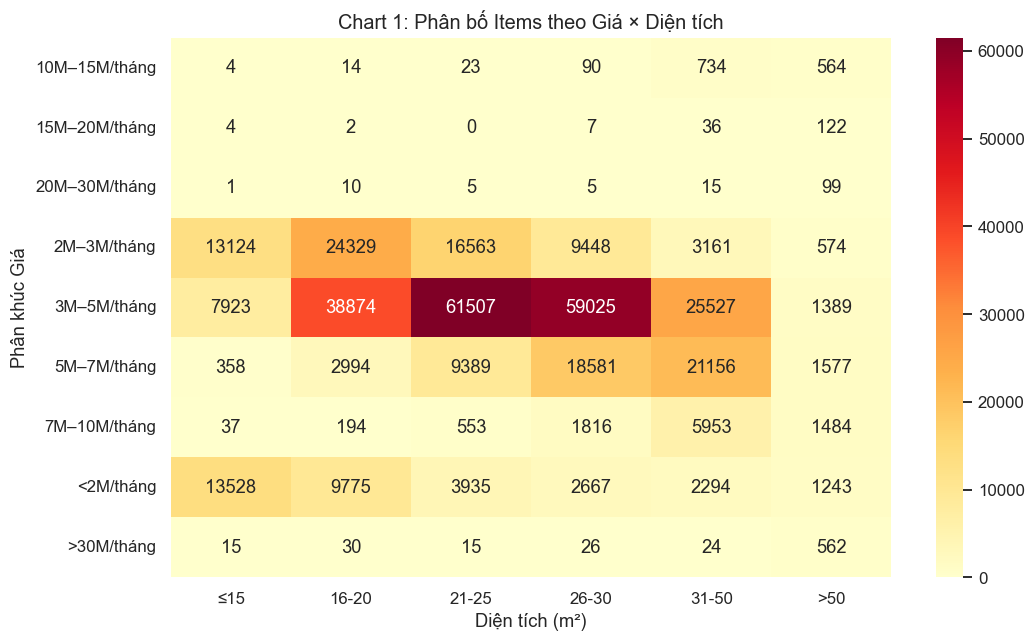

In [15]:
# Chart 1: Heatmap price_bucket × area_bin
fig, ax = plt.subplots(figsize=(10,6))
if 'price_bucket' in df_item.columns:
    hm1 = df_item.groupby(['price_bucket','area_bin'], observed=True)['item_id'].count().unstack(fill_value=0)
    sns.heatmap(hm1, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_title('Chart 1: Phân bố Items theo Giá × Diện tích', fontsize=13)
    ax.set_xlabel('Diện tích (m²)'); ax.set_ylabel('Phân khúc Giá')
else:
    ax.text(0.5,0.5,'Không có cột price_bucket',ha='center',transform=ax.transAxes)
plt.tight_layout(); plt.show()


**Chart 1 — Giá × Diện tích**: Ô đậm màu = nhiều tin. Phát hiện price-area mismatch (ví dụ giá cao nhưng diện tích nhỏ bất thường).

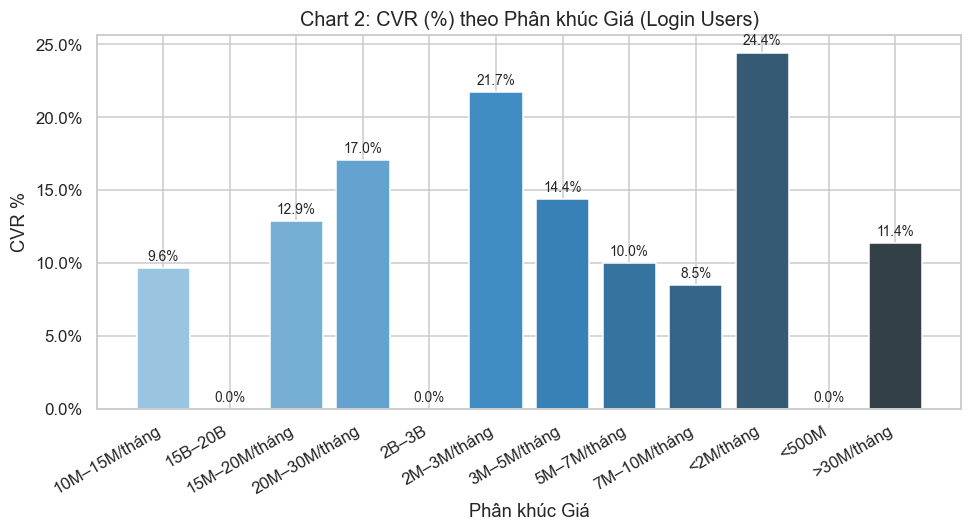

In [16]:
# Chart 2: CVR theo price_bucket (dựa trên login contacts)
if 'price_bucket' in df_item.columns:
    pc2 = df_item.groupby('price_bucket', observed=True).agg(
        total=('item_id','count'), leads=('has_lead','sum')
    ).assign(cvr_pct=lambda x: x['leads']/x['total']*100).reset_index()
    fig, ax = plt.subplots(figsize=(9,5))
    bars = ax.bar(pc2['price_bucket'].astype(str), pc2['cvr_pct'],
                  color=sns.color_palette('Blues_d', len(pc2)))
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_title('Chart 2: CVR (%) theo Phân khúc Giá (Login Users)', fontsize=13)
    ax.set_xlabel('Phân khúc Giá'); ax.set_ylabel('CVR %')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


**Chart 2 — CVR theo Giá (Login Users)**: Chỉ tính từ contacts của người dùng đã đăng nhập → sạch hơn và phản ánh intention thực sự hơn.

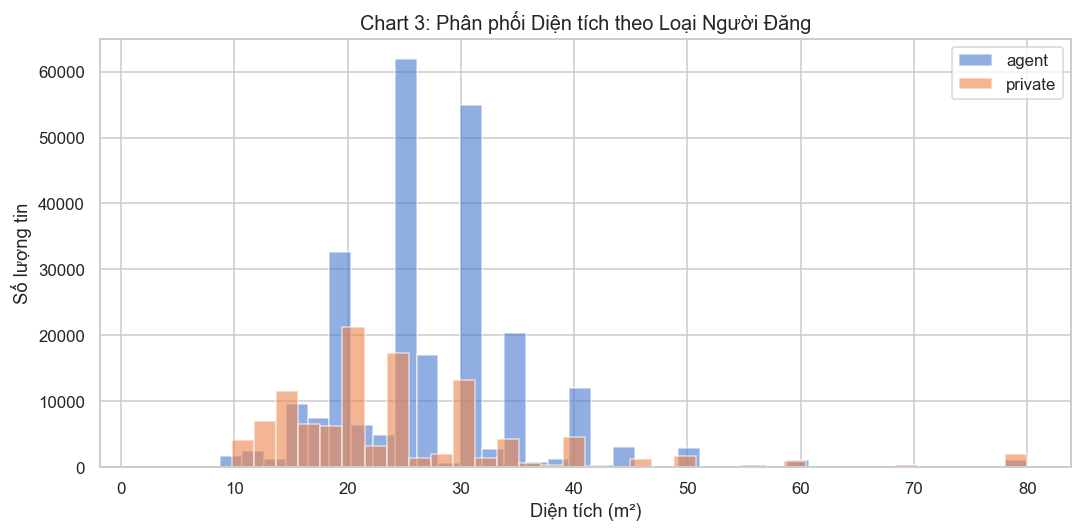

In [17]:
# Chart 3: Area distribution theo seller_type
fig, ax = plt.subplots(figsize=(10,5))
for stype, grp in df_item.groupby('seller_type', observed=True):
    ax.hist(grp['area_sqm'].dropna().clip(0,80), bins=40, alpha=0.6, label=str(stype))
ax.set_title('Chart 3: Phân phối Diện tích theo Loại Người Đăng', fontsize=13)
ax.set_xlabel('Diện tích (m²)'); ax.set_ylabel('Số lượng tin')
ax.legend(); plt.tight_layout(); plt.show()


**Chart 3 — Diện tích theo Seller Type**: Agency đăng phòng diện tích đồng đều hơn. Private seller đa dạng hơn về loại phòng.

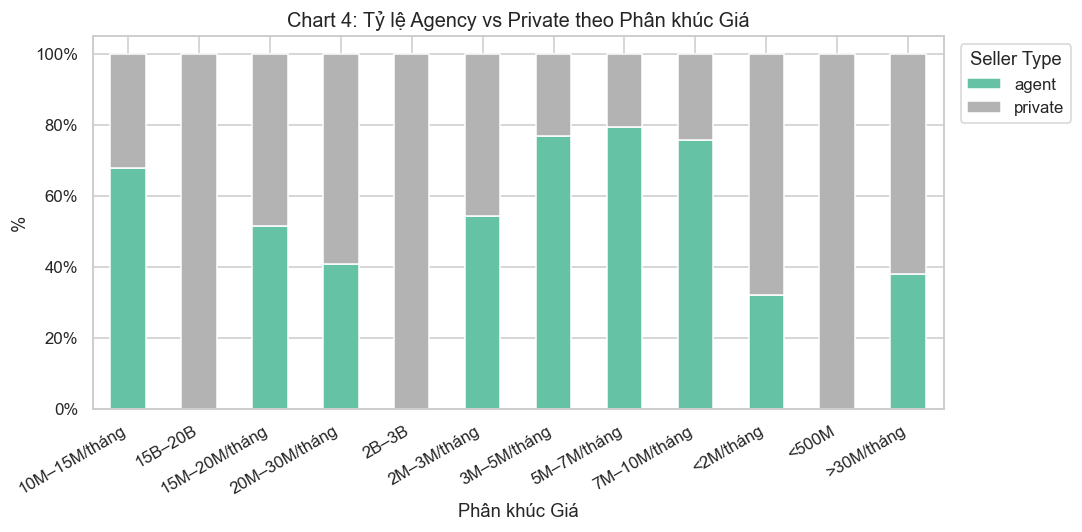

In [18]:
# Chart 4: Price bucket × seller_type stacked bar
if 'price_bucket' in df_item.columns and 'seller_type' in df_item.columns:
    pt4 = df_item.groupby(['price_bucket','seller_type'], observed=True)['item_id'].count().unstack(fill_value=0)
    pt4_pct = pt4.div(pt4.sum(axis=1), axis=0)*100
    fig, ax = plt.subplots(figsize=(10,5))
    pt4_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_title('Chart 4: Tỷ lệ Agency vs Private theo Phân khúc Giá', fontsize=13)
    ax.set_xlabel('Phân khúc Giá'); ax.set_ylabel('%')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Seller Type', bbox_to_anchor=(1.01,1))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


**Chart 4**: Phân khúc giá thấp nhiều private seller hơn (chủ nhà tự đăng). Giá cao hơn → agency chiếm ưu thế.

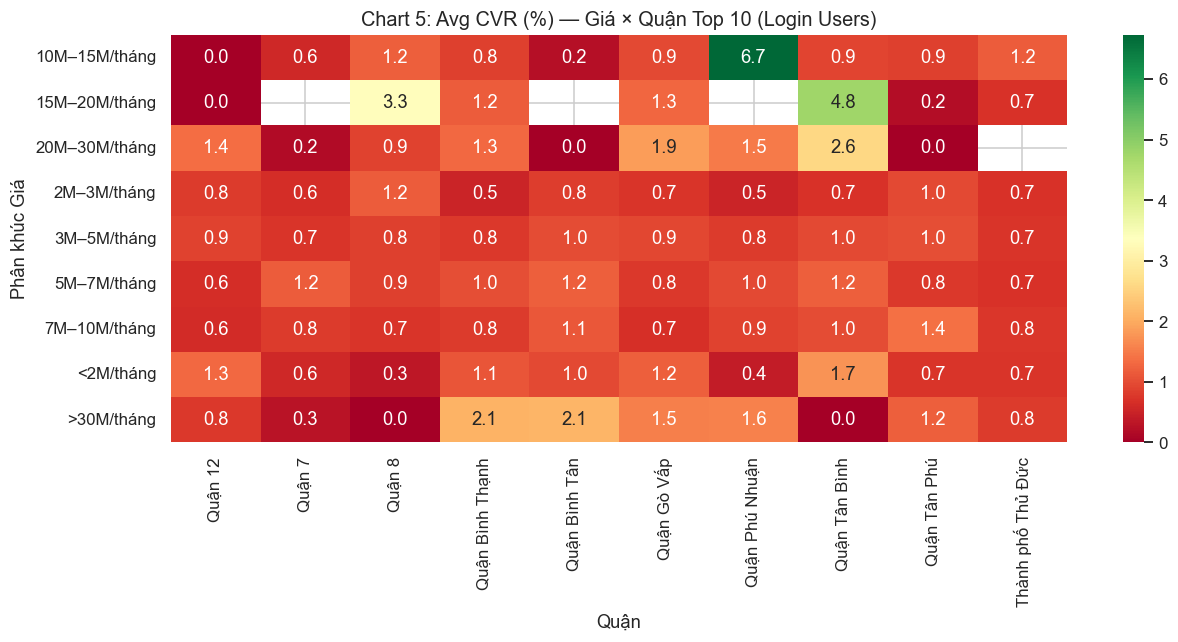

In [19]:
# Chart 5: Price bucket × district top10 — avg CVR
top10_dist = df_item['district_name'].value_counts().head(10).index.tolist() if 'district_name' in df_item.columns else []
if top10_dist and 'price_bucket' in df_item.columns:
    df5 = df_item[df_item['district_name'].isin(top10_dist)]
    hm5 = df5.groupby(['price_bucket','district_name'], observed=True)['cvr'].mean().unstack(fill_value=0)*100
    fig, ax = plt.subplots(figsize=(12,6))
    sns.heatmap(hm5, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
    ax.set_title('Chart 5: Avg CVR (%) — Giá × Quận Top 10 (Login Users)', fontsize=13)
    ax.set_xlabel('Quận'); ax.set_ylabel('Phân khúc Giá')
    plt.tight_layout(); plt.show()


**Chart 5**: Ô xanh đậm = cơ hội tốt (CVR cao, nhu cầu vượt cung). Ô đỏ = dư cung hoặc listing kém chất lượng.

---
# Zone 3 — Chất lượng Nội dung (5 charts)

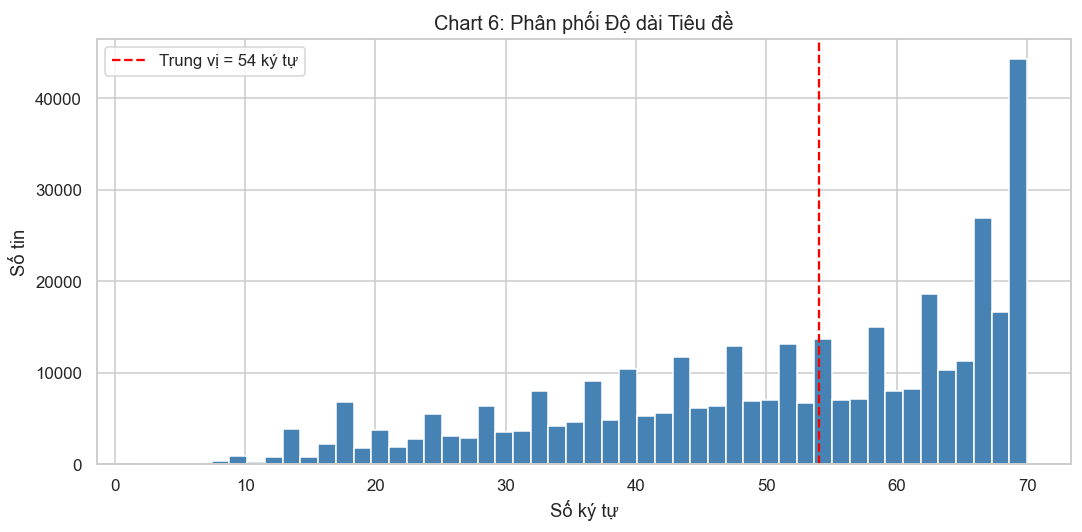

In [20]:
# Chart 6: Title length distribution
if 'title_len' in df_item.columns:
    fig, ax = plt.subplots(figsize=(10,5))
    ax.hist(df_item['title_len'].clip(0,150), bins=50, color='steelblue', edgecolor='white')
    med = df_item['title_len'].median()
    ax.axvline(med, color='red', linestyle='--', label=f'Trung vị = {med:.0f} ký tự')
    ax.set_title('Chart 6: Phân phối Độ dài Tiêu đề', fontsize=13)
    ax.set_xlabel('Số ký tự'); ax.set_ylabel('Số tin')
    ax.legend(); plt.tight_layout(); plt.show()


**Chart 6**: Tiêu đề < 20 ký tự thiếu thông tin. > 100 ký tự bị cắt trên mobile. Trung vị lý tưởng là 40-60 ký tự.

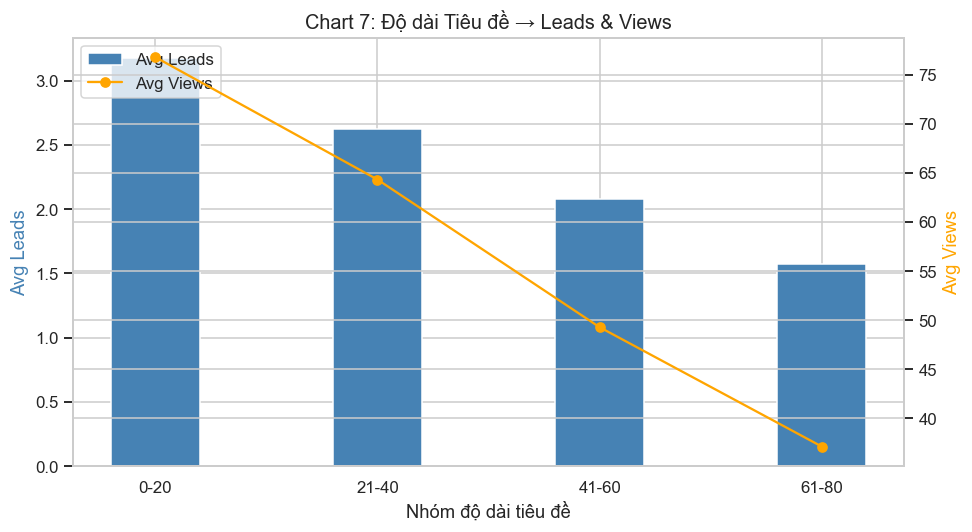

In [21]:
# Chart 7: Title length bins → avg leads & views
if 'title_len' in df_item.columns:
    df_item['title_bin'] = pd.cut(df_item['title_len'], bins=[0,20,40,60,80,999],
                                   labels=['0-20','21-40','41-60','61-80','>80'])
    gb7 = df_item.groupby('title_bin', observed=True).agg(
        avg_leads=('n_leads','mean'), avg_views=('total_views','mean'), count=('item_id','count')
    ).reset_index()
    fig, ax1 = plt.subplots(figsize=(9,5))
    ax2 = ax1.twinx()
    x = range(len(gb7))
    ax1.bar(x, gb7['avg_leads'], width=0.4, label='Avg Leads', color='steelblue')
    ax2.plot(x, gb7['avg_views'], 'o-', color='orange', label='Avg Views')
    ax1.set_xticks(x); ax1.set_xticklabels(gb7['title_bin'])
    ax1.set_xlabel('Nhóm độ dài tiêu đề'); ax1.set_ylabel('Avg Leads', color='steelblue')
    ax2.set_ylabel('Avg Views', color='orange')
    ax1.set_title('Chart 7: Độ dài Tiêu đề → Leads & Views', fontsize=13)
    lines1,labs1 = ax1.get_legend_handles_labels()
    lines2,labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labs1+labs2, loc='upper left')
    plt.tight_layout(); plt.show()


**Chart 7**: Tiêu đề 41-60 ký tự thường đạt leads và views cao nhất. Bằng chứng rõ ràng chất lượng tiêu đề ảnh hưởng trực tiếp đến hiệu quả listing.

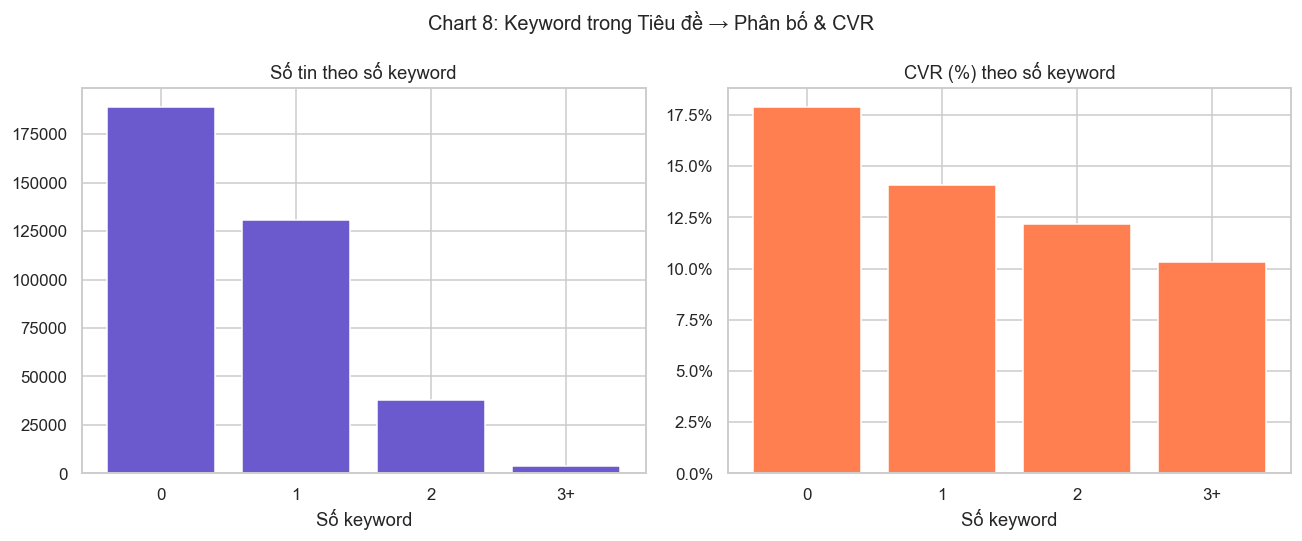

In [22]:
# Chart 8: Số keyword → CVR
if 'n_keywords' in df_item.columns:
    df_item['kw_group'] = df_item['n_keywords'].clip(0,3).map({0:'0',1:'1',2:'2',3:'3+'})
    gb8 = df_item.groupby('kw_group', observed=True).agg(
        count=('item_id','count'), cvr_pct=('has_lead','mean')
    ).reset_index()
    gb8['cvr_pct'] *= 100
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
    ax1.bar(gb8['kw_group'], gb8['count'], color='slateblue')
    ax1.set_title('Số tin theo số keyword'); ax1.set_xlabel('Số keyword')
    ax2.bar(gb8['kw_group'], gb8['cvr_pct'], color='coral')
    ax2.set_title('CVR (%) theo số keyword'); ax2.set_xlabel('Số keyword')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    fig.suptitle('Chart 8: Keyword trong Tiêu đề → Phân bố & CVR', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 8**: Listing có 2+ keyword tiện ích (nội thất, máy lạnh, ban công...) thường CVR cao hơn do thông tin đầy đủ hơn.

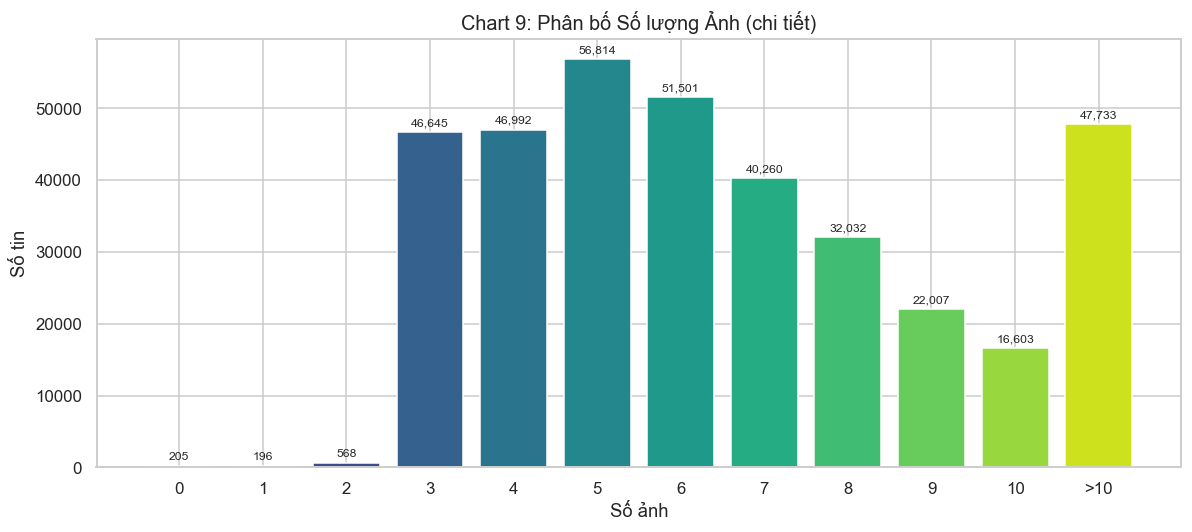

In [23]:
# Chart 9: Số ảnh granular
cnt_map = {i:str(i) for i in range(11)}; cnt_map[11]='>10'
img_s = df_item['images_count'].clip(0,11).map(cnt_map)
order = [str(i) for i in range(11)] + ['>10']
img_vc = img_s.value_counts().reindex([o for o in order if o in img_s.values], fill_value=0)
fig, ax = plt.subplots(figsize=(11,5))
bars9 = ax.bar(img_vc.index, img_vc.values, color=sns.color_palette('viridis', len(img_vc)))
ax.bar_label(bars9, labels=[f'{v:,}' for v in img_vc.values], padding=3, fontsize=8)
ax.set_title('Chart 9: Phân bố Số lượng Ảnh (chi tiết)', fontsize=13)
ax.set_xlabel('Số ảnh'); ax.set_ylabel('Số tin')
plt.tight_layout(); plt.show()


**Chart 9**: Tỷ lệ listing 0 ảnh là chỉ số data quality quan trọng. Khuyến nghị tối thiểu 5 ảnh cho phòng trọ.

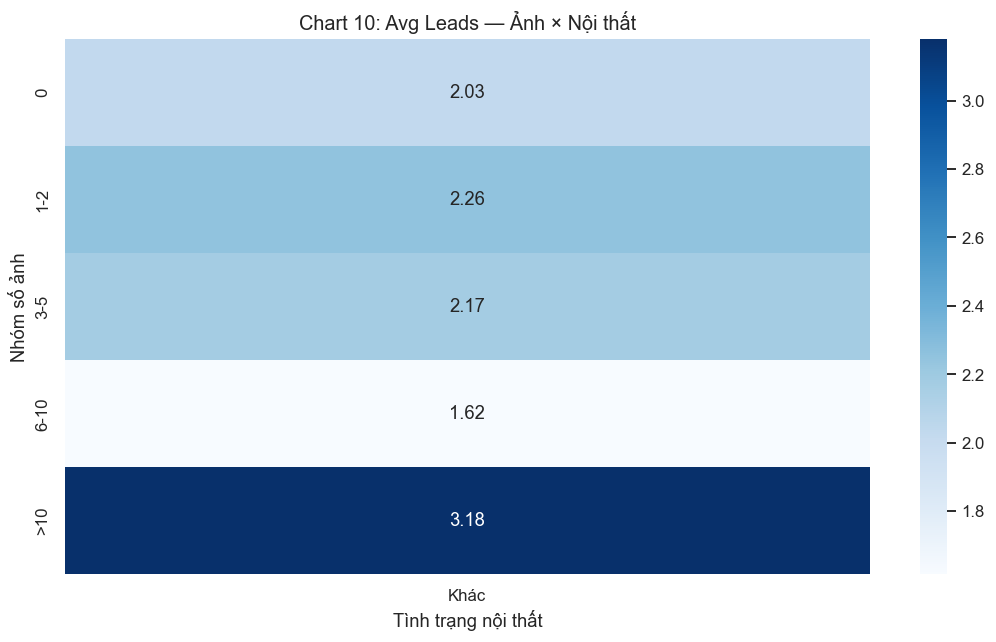

In [24]:
# Chart 10: img_bin × furnishing → avg leads
hm10 = df_item.groupby(['img_bin','furnishing_clean'], observed=True)['n_leads'].mean().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(hm10, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title('Chart 10: Avg Leads — Ảnh × Nội thất', fontsize=13)
ax.set_xlabel('Tình trạng nội thất'); ax.set_ylabel('Nhóm số ảnh')
plt.tight_layout(); plt.show()


**Chart 10**: Ô tối nhất = leads cao nhất. Nhiều ảnh + nội thất đầy đủ cộng hưởng nhau → tăng leads đáng kể.

---
# Zone 4 — Seller Intelligence (4 charts)

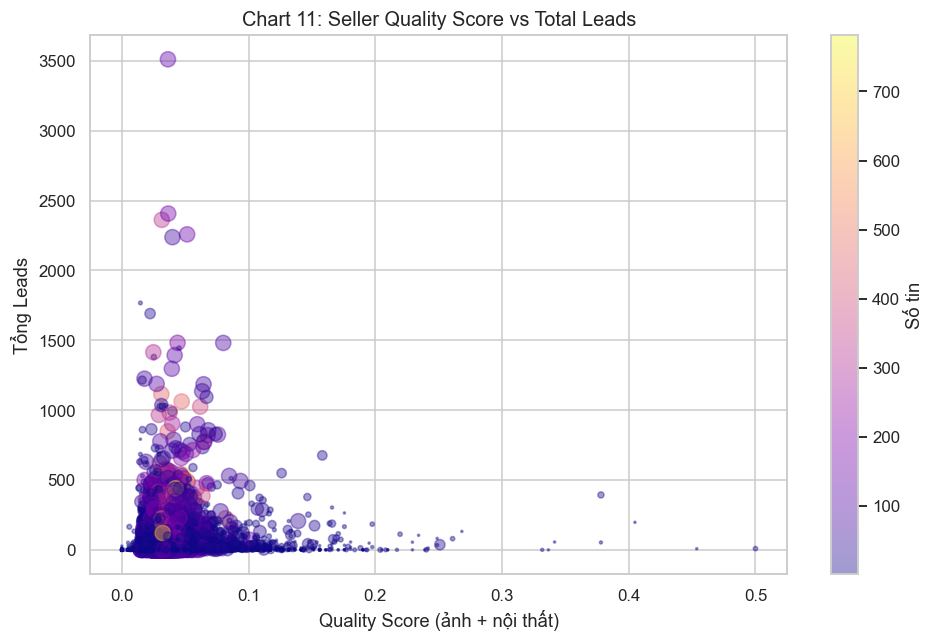

In [25]:
# Chart 11: Seller quality scatter
seller_q = df_item.groupby('seller_id', observed=True).agg(
    avg_images  =('images_count','mean'),
    n_listings  =('item_id','count'),
    total_leads =('n_leads','sum'),
    furn_rate   =('furnishing_clean', lambda x: (x=='Đầy đủ').mean())
).reset_index()
seller_q['quality_score'] = (seller_q['avg_images']/seller_q['avg_images'].max().clip(1) +
                              seller_q['furn_rate']) / 2
fig, ax = plt.subplots(figsize=(9,6))
sc = ax.scatter(seller_q['quality_score'], seller_q['total_leads'],
                alpha=0.4, s=seller_q['n_listings'].clip(1,50)*2,
                c=seller_q['n_listings'], cmap='plasma')
plt.colorbar(sc, ax=ax, label='Số tin')
ax.set_title('Chart 11: Seller Quality Score vs Total Leads', fontsize=13)
ax.set_xlabel('Quality Score (ảnh + nội thất)'); ax.set_ylabel('Tổng Leads')
plt.tight_layout(); plt.show()


**Chart 11**: Xu hướng dốc lên phải → seller đầu tư chất lượng nhận được nhiều leads hơn. Kích thước điểm = số tin đăng.

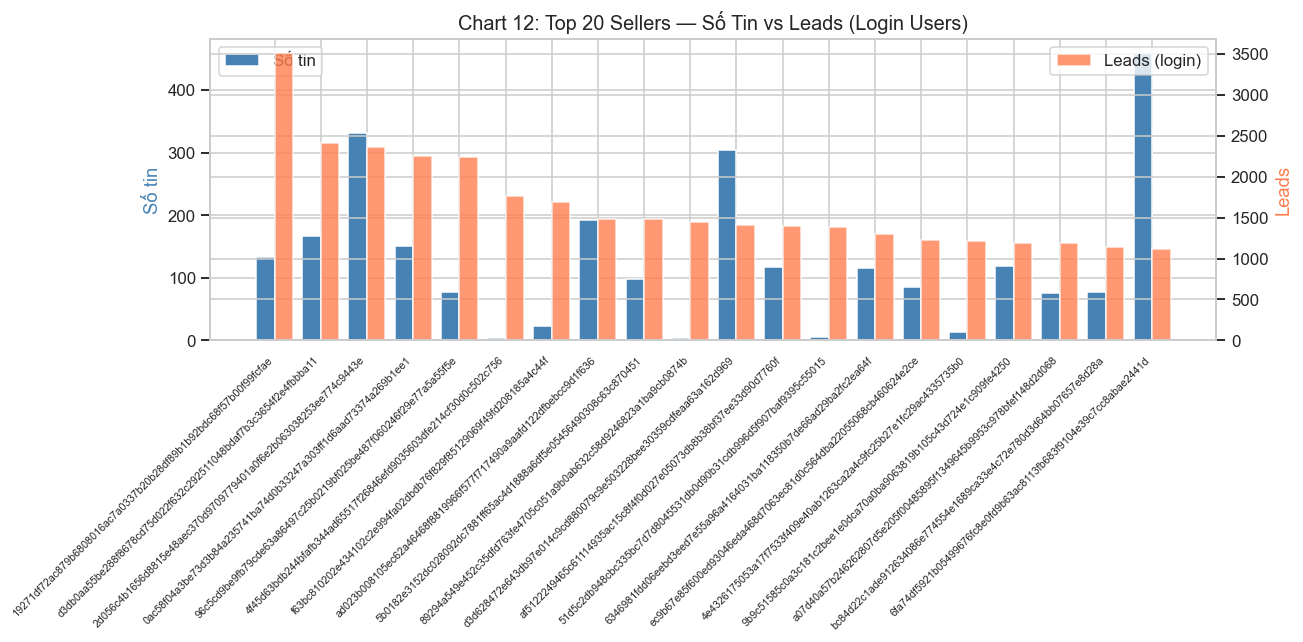

In [26]:
# Chart 12: Top 20 sellers
top20 = seller_q.nlargest(20,'total_leads')
fig, ax = plt.subplots(figsize=(12,6))
x12 = range(len(top20)); w = 0.4
ax.bar([i-w/2 for i in x12], top20['n_listings'], width=w, label='Số tin', color='steelblue')
ax2b = ax.twinx()
ax2b.bar([i+w/2 for i in x12], top20['total_leads'], width=w, label='Leads (login)', color='coral', alpha=0.8)
ax.set_xticks(x12)
ax.set_xticklabels(top20['seller_id'].astype(str), rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Số tin', color='steelblue'); ax2b.set_ylabel('Leads', color='coral')
ax.set_title('Chart 12: Top 20 Sellers — Số Tin vs Leads (Login Users)', fontsize=13)
ax.legend(loc='upper left'); ax2b.legend(loc='upper right')
plt.tight_layout(); plt.show()


**Chart 12**: So sánh số tin và leads từ login users. Seller ít tin nhưng leads cao = mỗi tin chất lượng tốt.

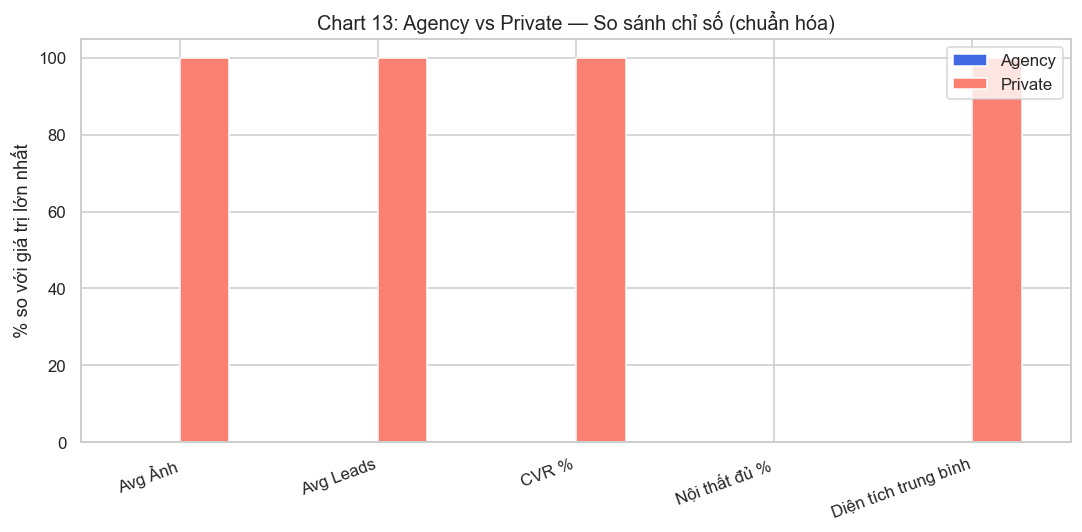


Giá trị tuyệt đối:
                      Agency  Private
Avg Ảnh                  NaN     6.93
Avg Leads                NaN     2.06
CVR %                    NaN    15.84
Nội thất đủ %            NaN     0.00
Diện tích trung bình     NaN    91.51


In [27]:
# Chart 13: Agency vs Private
ag = df_item[df_item['seller_type']=='agency']
pr = df_item[df_item['seller_type']!='agency']
comp13 = pd.DataFrame({
    'Agency' : [ag['images_count'].mean(), ag['n_leads'].mean(), ag['has_lead'].mean()*100,
                (ag['furnishing_clean']=='Đầy đủ').mean()*100, ag['area_sqm'].mean()],
    'Private': [pr['images_count'].mean(), pr['n_leads'].mean(), pr['has_lead'].mean()*100,
                (pr['furnishing_clean']=='Đầy đủ').mean()*100, pr['area_sqm'].mean()]
}, index=['Avg Ảnh','Avg Leads','CVR %','Nội thất đủ %','Diện tích trung bình'])
comp13_norm = comp13.div(comp13.max(axis=1).clip(0.001), axis=0)*100
fig, ax = plt.subplots(figsize=(10,5))
comp13_norm.plot(kind='bar', ax=ax, color=['royalblue','salmon'])
ax.set_title('Chart 13: Agency vs Private — So sánh chỉ số (chuẩn hóa)', fontsize=13)
ax.set_ylabel('% so với giá trị lớn nhất')
ax.set_xticklabels(comp13_norm.index, rotation=20, ha='right')
ax.legend(); plt.tight_layout(); plt.show()
print("\nGiá trị tuyệt đối:"); print(comp13.round(2))


**Chart 13**: Agency dẫn đầu về ảnh và nội thất. Private seller đôi khi CVR cao hơn vì chủ nhà phản hồi nhanh và linh hoạt hơn.

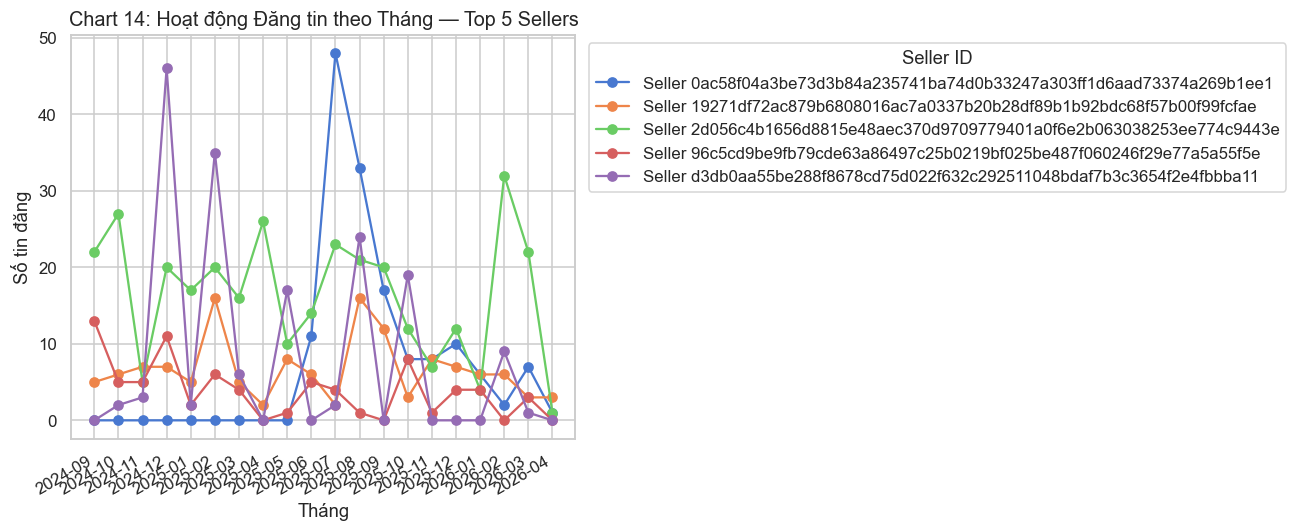

In [28]:
# Chart 14: Monthly activity top 5 sellers
top5_s = seller_q.nlargest(5,'total_leads')['seller_id'].tolist()
df14 = df_item[df_item['seller_id'].isin(top5_s)][['seller_id','posted_month']].dropna()
act14 = df14.groupby(['posted_month','seller_id']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12,5))
for col in act14.columns:
    ax.plot(act14.index, act14[col], marker='o', label=f'Seller {col}')
ax.set_title('Chart 14: Hoạt động Đăng tin theo Tháng — Top 5 Sellers', fontsize=13)
ax.set_xlabel('Tháng'); ax.set_ylabel('Số tin đăng')
ax.legend(title='Seller ID', bbox_to_anchor=(1.01,1))
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


**Chart 14**: Tín hiệu mùa vụ — seller tăng đột biến = mở rộng danh mục, seller giảm = đã cho thuê hết.

---
# Zone 5 — Địa lý Nâng cao (4 charts)

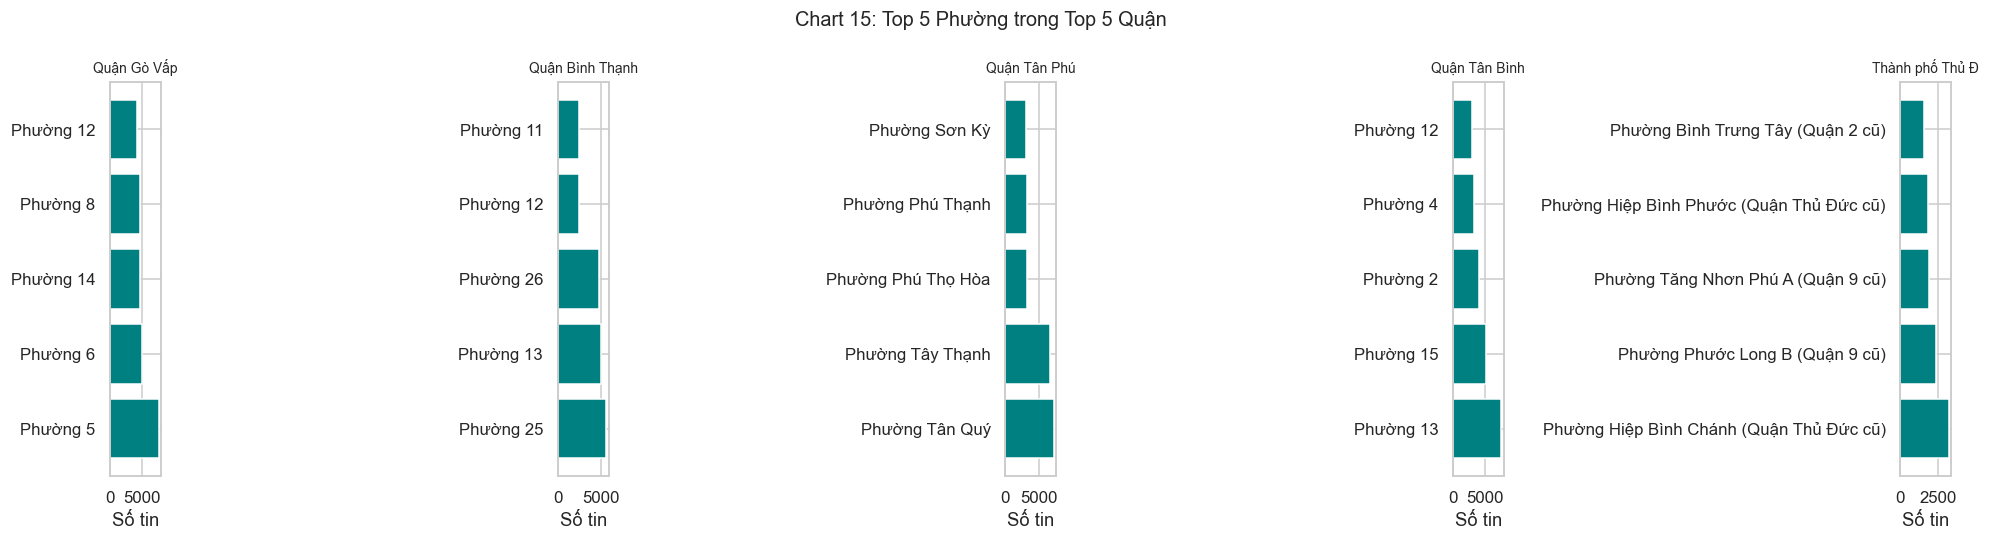

In [29]:
# Chart 15: Ward supply trong top 5 districts
top5_dist = df_item['district_name'].value_counts().head(5).index.tolist() if 'district_name' in df_item.columns else []
if top5_dist and 'ward_name' in df_item.columns:
    ws = df_item[df_item['district_name'].isin(top5_dist)].groupby(
        ['district_name','ward_name'])['item_id'].count().reset_index()
    fig, axes = plt.subplots(1,5,figsize=(18,5))
    for ax, dist in zip(axes, top5_dist):
        sub = ws[ws['district_name']==dist].nlargest(5,'item_id')
        ax.barh(sub['ward_name'], sub['item_id'], color='teal')
        ax.set_title(str(dist)[:15], fontsize=9); ax.set_xlabel('Số tin')
    fig.suptitle('Chart 15: Top 5 Phường trong Top 5 Quận', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 15**: Phường nào chiếm >50% nguồn cung trong quận → nguồn cung tập trung, cơ hội cho phường khác.

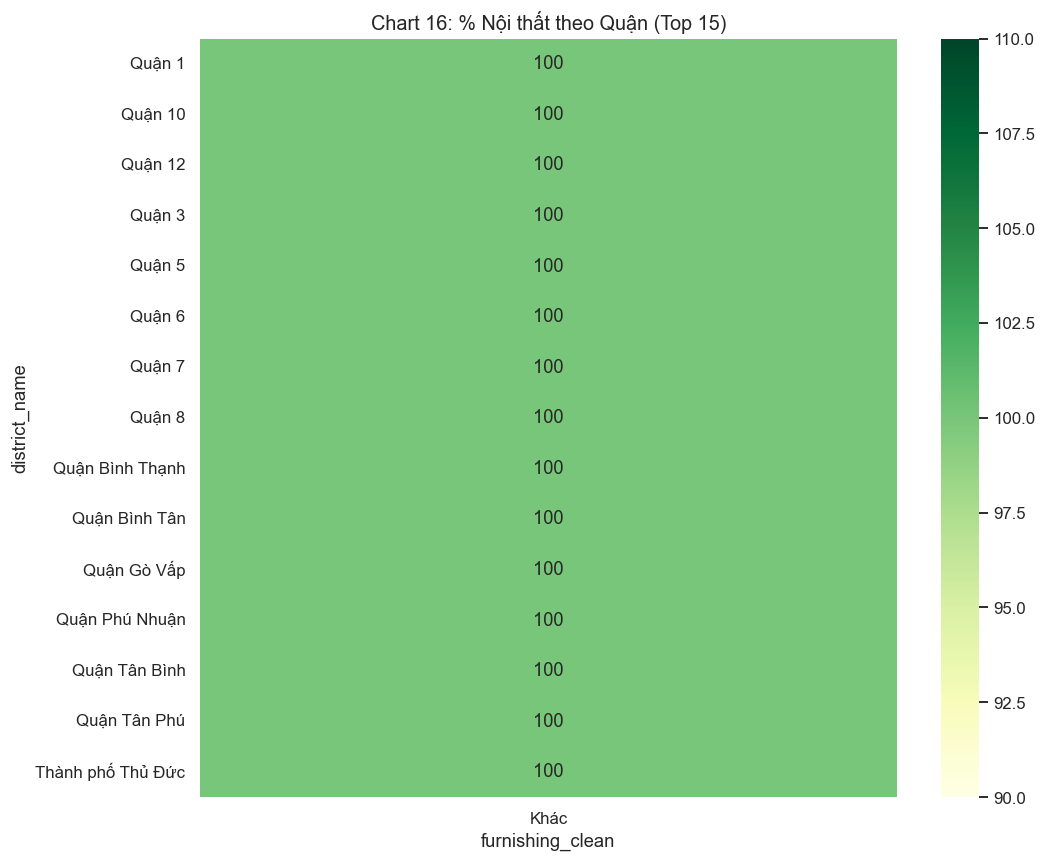

In [30]:
# Chart 16: District × furnishing heatmap
top15_dist = df_item['district_name'].value_counts().head(15).index.tolist() if 'district_name' in df_item.columns else []
if top15_dist:
    df16 = df_item[df_item['district_name'].isin(top15_dist)]
    hm16 = df16.groupby(['district_name','furnishing_clean'], observed=True)['item_id'].count().unstack(fill_value=0)
    hm16_pct = hm16.div(hm16.sum(axis=1), axis=0)*100
    fig, ax = plt.subplots(figsize=(10,8))
    sns.heatmap(hm16_pct, annot=True, fmt='.0f', cmap='YlGn', ax=ax)
    ax.set_title('Chart 16: % Nội thất theo Quận (Top 15)', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 16**: Quận nhiều nội thất đầy đủ = thị trường cao cấp hơn. Quận ít nội thất = thị trường sinh viên/công nhân.

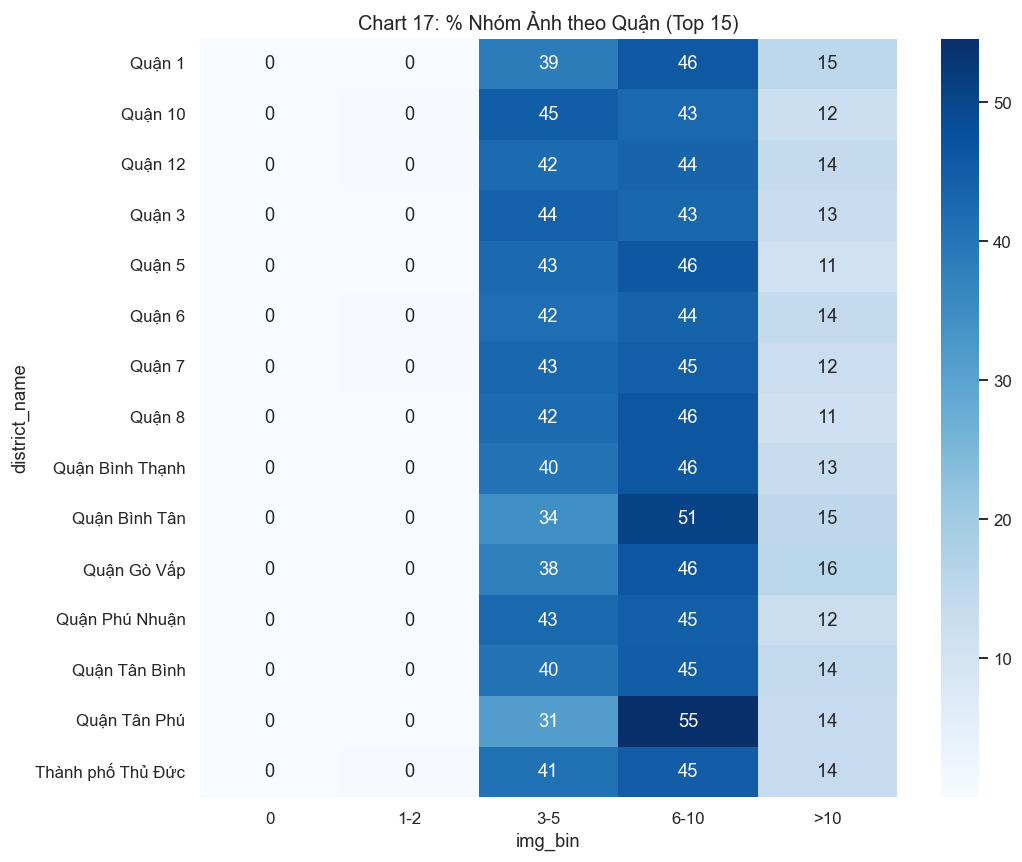

In [31]:
# Chart 17: District × img_bin heatmap
if top15_dist:
    hm17 = df_item[df_item['district_name'].isin(top15_dist)].groupby(
        ['district_name','img_bin'], observed=True)['item_id'].count().unstack(fill_value=0)
    hm17_pct = hm17.div(hm17.sum(axis=1), axis=0)*100
    fig, ax = plt.subplots(figsize=(10,8))
    sns.heatmap(hm17_pct, annot=True, fmt='.0f', cmap='Blues', ax=ax)
    ax.set_title('Chart 17: % Nhóm Ảnh theo Quận (Top 15)', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 17**: Quận nhiều listing 0 ảnh → vấn đề chất lượng cục bộ. CVR vẫn cao → nhu cầu mạnh, seller chưa khai thác hết.

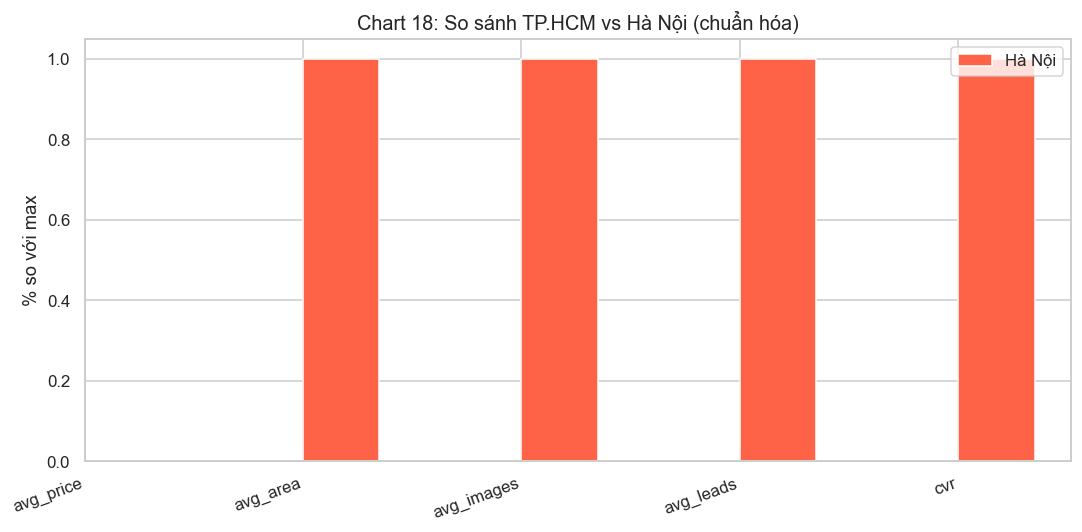


Giá trị tuyệt đối:
city_group  Hà Nội
avg_price      NaN
avg_area    80.486
avg_images   5.665
avg_leads    2.085
cvr          0.193


In [32]:
# Chart 18: TP.HCM vs Hà Nội
if 'city_name' in df_item.columns:
    def city_flag(v):
        if pd.isna(v): return 'Khác'
        v = str(v).lower()
        if any(k in v for k in ['chi minh','hcm','sai gon','tp.hcm']): return 'TP.HCM'
        if any(k in v for k in ['ha noi','hanoi','hà nội']): return 'Hà Nội'
        return 'Khác'
    df_item['city_group'] = df_item['city_name'].apply(city_flag)
    cg = df_item[df_item['city_group'].isin(['TP.HCM','Hà Nội'])].groupby('city_group').agg(
        avg_price =('price_value','mean'),
        avg_area  =('area_sqm','mean'),
        avg_images=('images_count','mean'),
        avg_leads =('n_leads','mean'),
        cvr       =('has_lead','mean')
    ).T
    city_norm = cg.div(cg.max(axis=1).clip(0.001), axis=0)
    fig, ax = plt.subplots(figsize=(10,5))
    x18 = range(len(city_norm)); w18=0.35
    if 'TP.HCM' in city_norm: ax.bar([i-w18/2 for i in x18], city_norm['TP.HCM'], w18, label='TP.HCM', color='royalblue')
    if 'Hà Nội' in city_norm: ax.bar([i+w18/2 for i in x18], city_norm['Hà Nội'], w18, label='Hà Nội', color='tomato')
    ax.set_xticks(x18); ax.set_xticklabels(city_norm.index, rotation=20, ha='right')
    ax.set_title('Chart 18: So sánh TP.HCM vs Hà Nội (chuẩn hóa)', fontsize=13)
    ax.set_ylabel('% so với max'); ax.legend(); plt.tight_layout(); plt.show()
    print("\nGiá trị tuyệt đối:"); print(cg.round(3))


**Chart 18**: TP.HCM thường giá cao hơn và diện tích nhỏ hơn do mật độ đô thị. CVR khác nhau phản ánh mức độ cạnh tranh.

---
# Zone 6 — Hành vi User (Login-only, 6 charts — DuckDB)

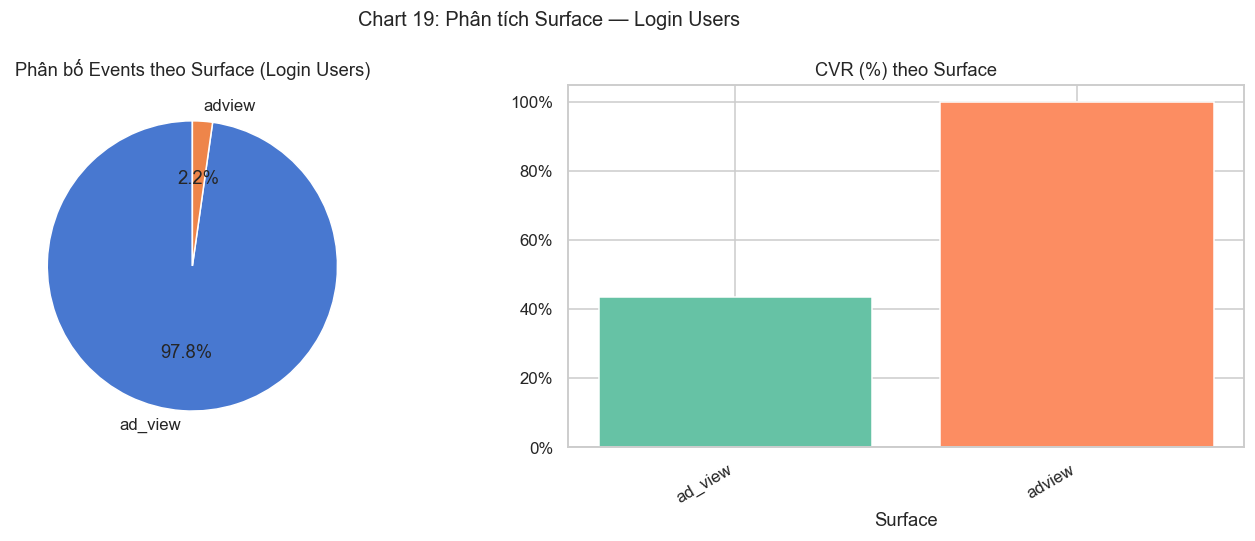

surface    total   contacts       cvr
ad_view 25509939 11085173.0  43.45433
 adview   581942   581942.0 100.00000


In [33]:
# Chart 19: Surface breakdown
df19 = con.execute("""
SELECT surface, COUNT(*) AS total,
       SUM(CAST(is_contact AS INTEGER)) AS contacts
FROM ev_1050
GROUP BY surface ORDER BY total DESC LIMIT 10
""").df()
df19['cvr'] = df19['contacts']/df19['total']*100
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
ax1.pie(df19['total'], labels=df19['surface'], autopct='%1.1f%%', startangle=90)
ax1.set_title('Phân bố Events theo Surface (Login Users)')
ax2.bar(df19['surface'].astype(str), df19['cvr'], color=sns.color_palette('Set2',len(df19)))
ax2.set_title('CVR (%) theo Surface'); ax2.set_xlabel('Surface')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30, ha='right')
fig.suptitle('Chart 19: Phân tích Surface — Login Users', fontsize=13)
plt.tight_layout(); plt.show()
print(df19[['surface','total','contacts','cvr']].to_string(index=False))


**Chart 19**: Surface cho biết login users tìm thấy listing qua đâu. Browse thường có intent cao hơn recommendation.

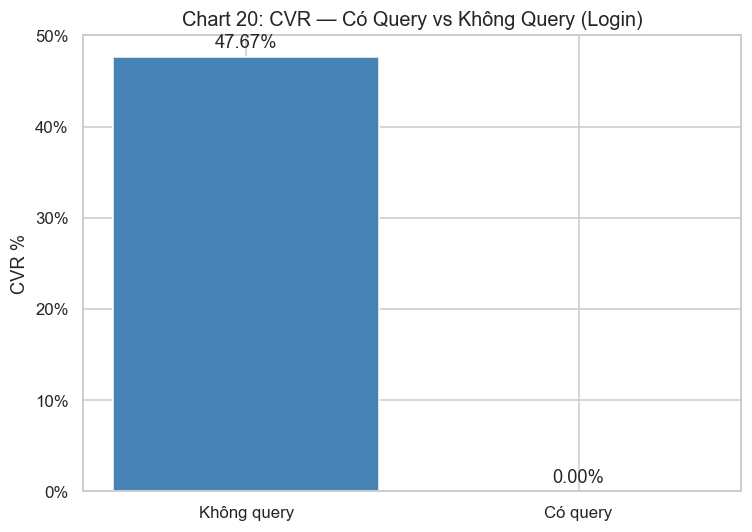

            qg     total    contacts   cvr_pct
0  Không query  24472351  11667115.0  47.67468
1     Có query   1619530         0.0   0.00000


In [34]:
# Chart 20: Query vs No Query → CVR
df20 = con.execute("""
SELECT
    CASE WHEN query IS NOT NULL AND query != '' THEN 'Có query' ELSE 'Không query' END AS qg,
    COUNT(*) AS total,
    SUM(CAST(is_contact AS INTEGER)) AS contacts
FROM ev_1050 GROUP BY 1
""").df()
df20['cvr_pct'] = df20['contacts']/df20['total']*100
fig, ax = plt.subplots(figsize=(7,5))
bars20 = ax.bar(df20['qg'], df20['cvr_pct'], color=['steelblue','coral'])
ax.bar_label(bars20, fmt='%.2f%%', padding=3)
ax.set_title('Chart 20: CVR — Có Query vs Không Query (Login)', fontsize=13)
ax.set_ylabel('CVR %'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()
print(df20)


**Chart 20**: Login users tìm kiếm có từ khóa cụ thể → intent cao hơn → CVR thường cao hơn.

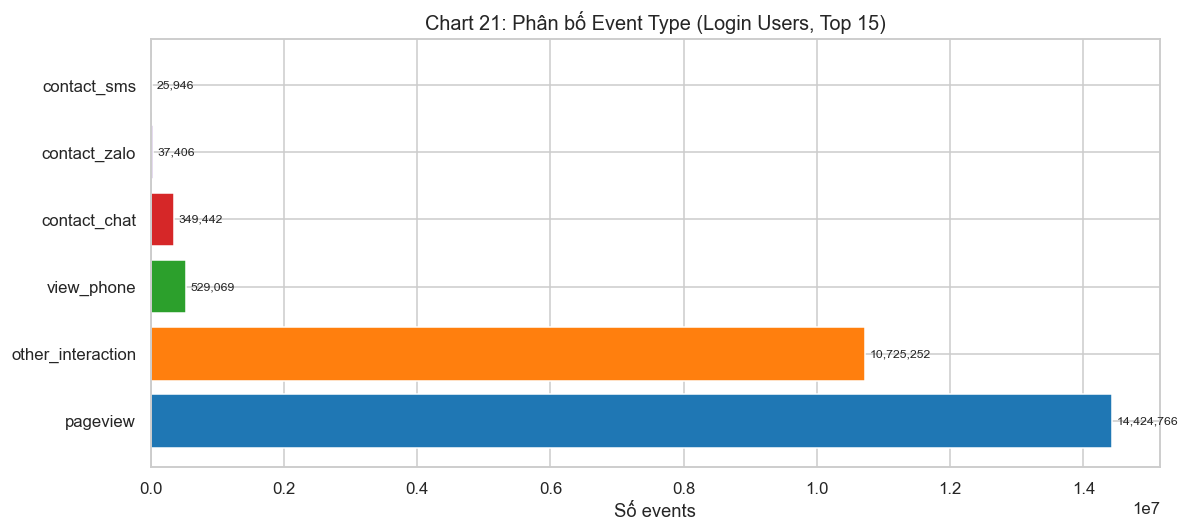

       event_type      cnt
         pageview 14424766
other_interaction 10725252
       view_phone   529069
     contact_chat   349442
     contact_zalo    37406
      contact_sms    25946


In [35]:
# Chart 21: Event type distribution
df21 = con.execute("""
SELECT event_type, COUNT(*) AS cnt
FROM ev_1050
GROUP BY event_type ORDER BY cnt DESC LIMIT 15
""").df()
fig, ax = plt.subplots(figsize=(11,5))
bars21 = ax.barh(df21['event_type'], df21['cnt'], color=sns.color_palette('tab10',len(df21)))
ax.set_title('Chart 21: Phân bố Event Type (Login Users, Top 15)', fontsize=13)
ax.set_xlabel('Số events')
ax.bar_label(bars21, labels=[f'{v:,.0f}' for v in df21['cnt']], padding=3, fontsize=8)
plt.tight_layout(); plt.show()
print(df21.to_string(index=False))


**Chart 21**: Phân bố event của login users. Tỷ lệ `is_contact=True` trên tổng events là CVR tổng thể. Event type tiết lộ hành vi tìm kiếm phòng.

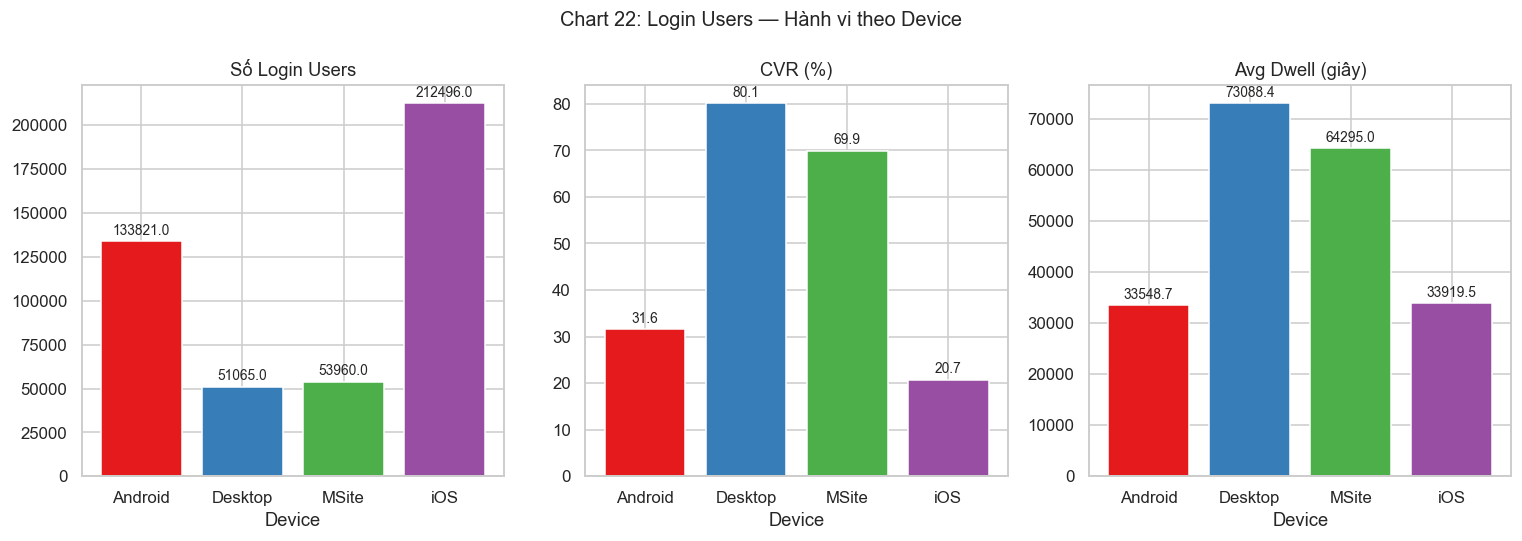

 device  n_users   cvr_pct  avg_dwell
Android   133821 31.617547    33548.7
Desktop    51065 80.120370    73088.4
  MSite    53960 69.939237    64295.0
    iOS   212496 20.683641    33919.5


In [36]:
# Chart 22: Login device × CVR (tất cả login rồi nên phân tích theo device)
df22 = con.execute("""
SELECT
    device,
    COUNT(*)                                  AS n_events,
    COUNT(DISTINCT user_id)                   AS n_users,
    SUM(CAST(is_contact AS INTEGER))          AS contacts,
    ROUND(AVG(dwell_time_sec),1)              AS avg_dwell
FROM ev_1050
WHERE device IS NOT NULL
GROUP BY device
""").df()
df22['cvr_pct'] = df22['contacts']/df22['n_events']*100

fig, axes = plt.subplots(1,3,figsize=(14,5))
for ax, (col,title) in zip(axes,[('n_users','Số Login Users'),('cvr_pct','CVR (%)'),('avg_dwell','Avg Dwell (giây)')]):
    bars = ax.bar(df22['device'], df22[col], color=sns.color_palette('Set1',len(df22)))
    ax.set_title(title); ax.set_xlabel('Device')
    for bar,v in zip(bars, df22[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(df22[col])*0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Chart 22: Login Users — Hành vi theo Device', fontsize=13)
plt.tight_layout(); plt.show()
print(df22[['device','n_users','cvr_pct','avg_dwell']].to_string(index=False))


**Chart 22**: Đã là login users nên phân tích sâu theo device. Mobile vs Desktop vs Tablet có CVR và dwell time khác nhau → tối ưu UX theo platform.

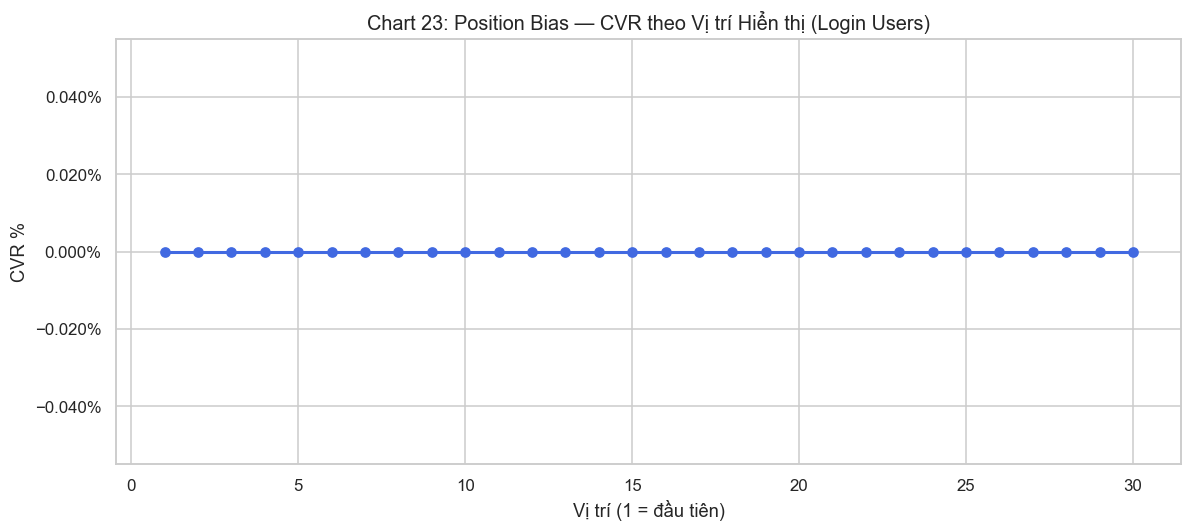

In [37]:
# Chart 23: Position bias curve
df23 = con.execute("""
SELECT CAST(position AS INTEGER) AS pos,
       COUNT(*) AS total,
       SUM(CAST(is_contact AS INTEGER)) AS contacts
FROM ev_1050
WHERE position IS NOT NULL AND CAST(position AS INTEGER) BETWEEN 1 AND 30
GROUP BY pos ORDER BY pos
""").df()
df23['cvr'] = df23['contacts']/df23['total']*100
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(df23['pos'], df23['cvr'], 'o-', color='royalblue', linewidth=2)
ax.fill_between(df23['pos'], df23['cvr'], alpha=0.2)
ax.set_title('Chart 23: Position Bias — CVR theo Vị trí Hiển thị (Login Users)', fontsize=13)
ax.set_xlabel('Vị trí (1 = đầu tiên)'); ax.set_ylabel('CVR %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()


**Chart 23**: CVR giảm dần theo vị trí — listing vị trí 1-3 nhận nhiều contact nhất. Bằng chứng về giá trị của ranking/SEO.

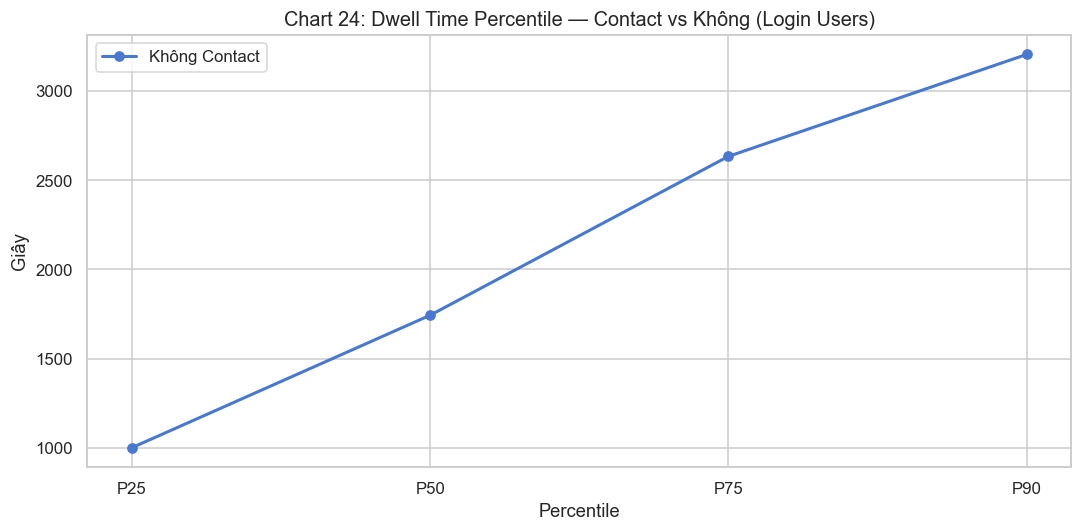

62023

In [38]:
# Chart 24: Dwell time — contact vs no-contact
df24 = con.execute("""
SELECT dwell_time_sec,
       CASE WHEN is_contact THEN 'Có Contact' ELSE 'Không Contact' END AS contact_flag
FROM ev_1050
WHERE dwell_time_sec IS NOT NULL AND dwell_time_sec > 0 AND dwell_time_sec < 3600
LIMIT 500000
""").df()
fig, ax = plt.subplots(figsize=(10,5))
for flag, grp in df24.groupby('contact_flag'):
    pcts = np.percentile(grp['dwell_time_sec'].dropna(), [25,50,75,90])
    ax.plot(['P25','P50','P75','P90'], pcts, marker='o', label=flag, linewidth=2)
ax.set_title('Chart 24: Dwell Time Percentile — Contact vs Không (Login Users)', fontsize=13)
ax.set_xlabel('Percentile'); ax.set_ylabel('Giây')
ax.legend(); plt.tight_layout(); plt.show()
del df24; gc.collect()


**Chart 24**: Login users xem trang lâu hơn có xu hướng liên hệ cao hơn. Dwell time là tín hiệu tốt để predict conversion intent.

---
# Zone 7 — Vòng đời Listing (4 charts)

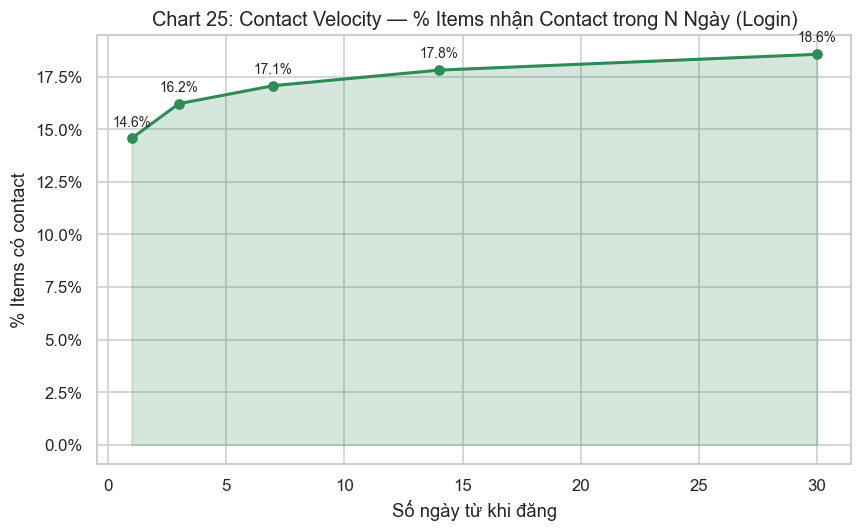

In [39]:
# Chart 25: Contact velocity
df_item['days_to_first'] = (df_item['first_contact'] - df_item['posted_date']).dt.days
thresholds = [1,3,7,14,30]
vel = [(df_item['days_to_first'] <= t).sum()/len(df_item)*100 for t in thresholds]
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(thresholds, vel, 'o-', color='seagreen', linewidth=2)
ax.fill_between(thresholds, vel, alpha=0.2, color='seagreen')
for t,p in zip(thresholds,vel):
    ax.annotate(f'{p:.1f}%', (t,p), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax.set_title('Chart 25: Contact Velocity — % Items nhận Contact trong N Ngày (Login)', fontsize=13)
ax.set_xlabel('Số ngày từ khi đăng'); ax.set_ylabel('% Items có contact')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()


**Chart 25**: Đường dốc lên nhanh → thị trường phòng trọ quyết định trong tuần. Listing không có contact sau 14 ngày thường có vấn đề chất lượng hoặc giá.

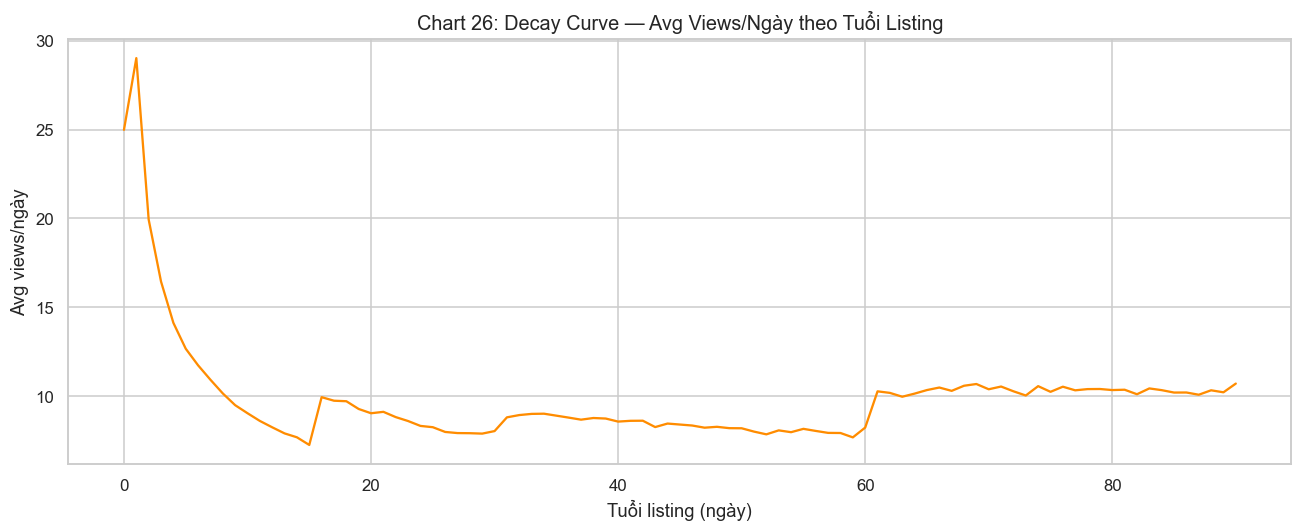

In [40]:
# Chart 26: Views decay theo listing_age_days
df26 = con.execute("""
SELECT listing_age_days AS age, AVG(views_24h) AS avg_views
FROM snap_raw
WHERE views_24h IS NOT NULL AND listing_age_days BETWEEN 0 AND 90
GROUP BY listing_age_days ORDER BY listing_age_days
""").df()
if len(df26):
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(df26['age'], df26['avg_views'], color='darkorange', linewidth=1.5)
    ax.set_title('Chart 26: Decay Curve — Avg Views/Ngày theo Tuổi Listing', fontsize=13)
    ax.set_xlabel('Tuổi listing (ngày)'); ax.set_ylabel('Avg views/ngày')
    plt.tight_layout(); plt.show()


**Chart 26**: Views giảm tự nhiên theo thời gian. Nên re-bump listing sau 7 ngày để duy trì visibility.

Dead listings: 304,297 / 361,556 = 84.2%


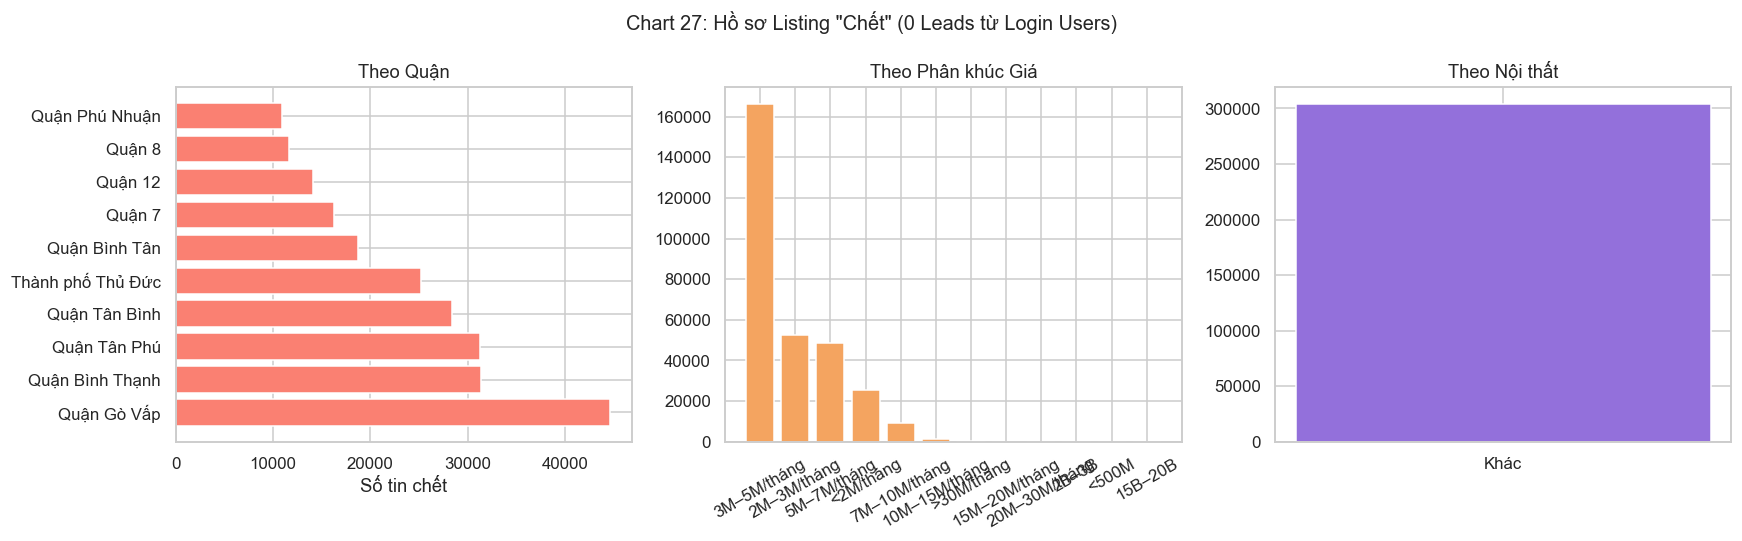

In [41]:
# Chart 27: Dead listings profile
dead = df_item[df_item['n_leads'] == 0].copy()
print(f"Dead listings: {len(dead):,} / {len(df_item):,} = {len(dead)/len(df_item)*100:.1f}%")
fig, axes = plt.subplots(1,3,figsize=(16,5))
if 'district_name' in dead.columns:
    dd = dead['district_name'].value_counts().head(10)
    axes[0].barh(dd.index, dd.values, color='salmon')
    axes[0].set_title('Theo Quận'); axes[0].set_xlabel('Số tin chết')
if 'price_bucket' in dead.columns:
    dp = dead['price_bucket'].value_counts()
    axes[1].bar(dp.index.astype(str), dp.values, color='sandybrown')
    axes[1].set_title('Theo Phân khúc Giá'); axes[1].tick_params(axis='x', rotation=30)
df27_f = dead['furnishing_clean'].value_counts()
axes[2].bar(df27_f.index, df27_f.values, color='mediumpurple')
axes[2].set_title('Theo Nội thất')
fig.suptitle('Chart 27: Hồ sơ Listing "Chết" (0 Leads từ Login Users)', fontsize=13)
plt.tight_layout(); plt.show()


**Chart 27**: Listing 0 contact (từ login users) tập trung ở đâu → xác định vấn đề cục bộ về dư cung, giá, hoặc chất lượng nội dung.

Sellers nghi ngờ relist: 13,172


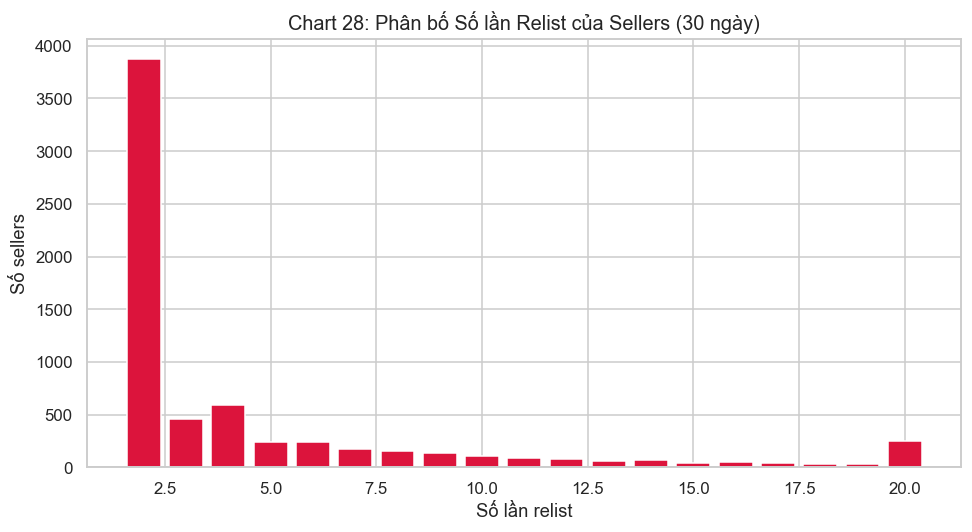

In [42]:
# Chart 28: Relisting detection
relist_keys = [c for c in ['seller_id','ward_name','price_bucket'] if c in df_item.columns]
if len(relist_keys) >= 2:
    rg = df_item.groupby(relist_keys, observed=True).agg(
        n_list    =('item_id','count'),
        date_range=('posted_date', lambda x: (x.max()-x.min()).days if len(x)>1 else 0)
    ).reset_index()
    rc = rg[(rg['n_list']>1) & (rg['date_range']<=30)]
    relist_per_seller = rc.groupby('seller_id', observed=True)['n_list'].sum()
    fig, ax = plt.subplots(figsize=(9,5))
    rh = relist_per_seller.clip(0,20).value_counts().sort_index()
    ax.bar(rh.index, rh.values, color='crimson')
    ax.set_title('Chart 28: Phân bố Số lần Relist của Sellers (30 ngày)', fontsize=13)
    ax.set_xlabel('Số lần relist'); ax.set_ylabel('Số sellers')
    print(f"Sellers nghi ngờ relist: {len(rc):,}")
    plt.tight_layout(); plt.show()


**Chart 28**: Sellers relist >10 lần trong 30 ngày → có thể spam (đăng/xóa/đăng lại để luôn ở đầu). Cần kiểm soát để đảm bảo trải nghiệm tốt.

---
# Zone 8 — Cross-dimensional Analysis (4 charts)

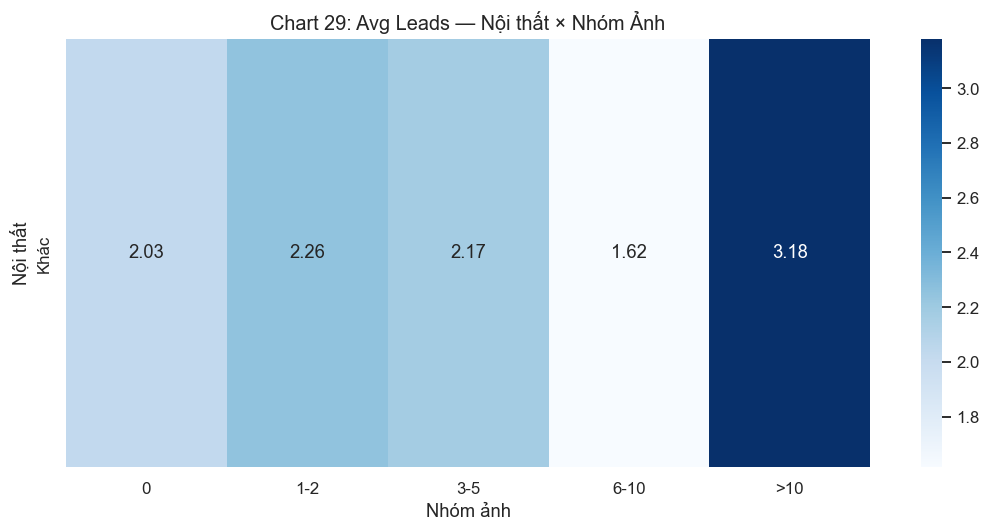

In [43]:
# Chart 29: Furnishing × img_bin → avg leads
hm29 = df_item.groupby(['furnishing_clean','img_bin'], observed=True)['n_leads'].mean().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(hm29, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title('Chart 29: Avg Leads — Nội thất × Nhóm Ảnh', fontsize=13)
ax.set_xlabel('Nhóm ảnh'); ax.set_ylabel('Nội thất')
plt.tight_layout(); plt.show()


**Chart 29**: Kết hợp nội thất đầy đủ + nhiều ảnh → leads cao nhất. Hai yếu tố này cộng hưởng nhau.

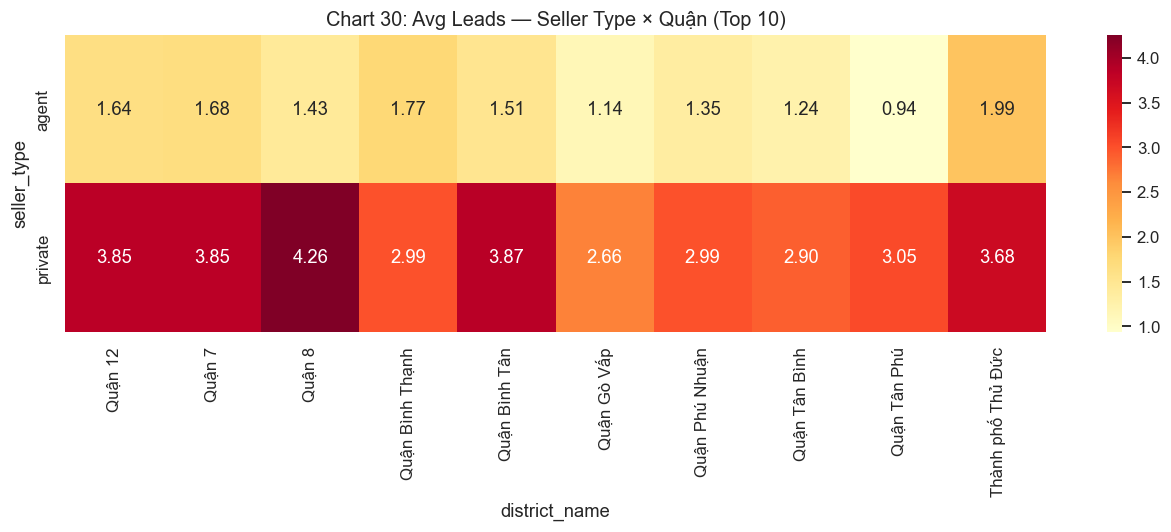

In [44]:
# Chart 30: seller_type × district → avg leads
if top10_dist and 'seller_type' in df_item.columns:
    hm30 = df_item[df_item['district_name'].isin(top10_dist)].groupby(
        ['seller_type','district_name'], observed=True)['n_leads'].mean().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12,5))
    sns.heatmap(hm30, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
    ax.set_title('Chart 30: Avg Leads — Seller Type × Quận (Top 10)', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 30**: Agency dẫn đầu ở quận trung tâm. Private seller ưu thế ở ngoại ô do hiểu biết địa phương.

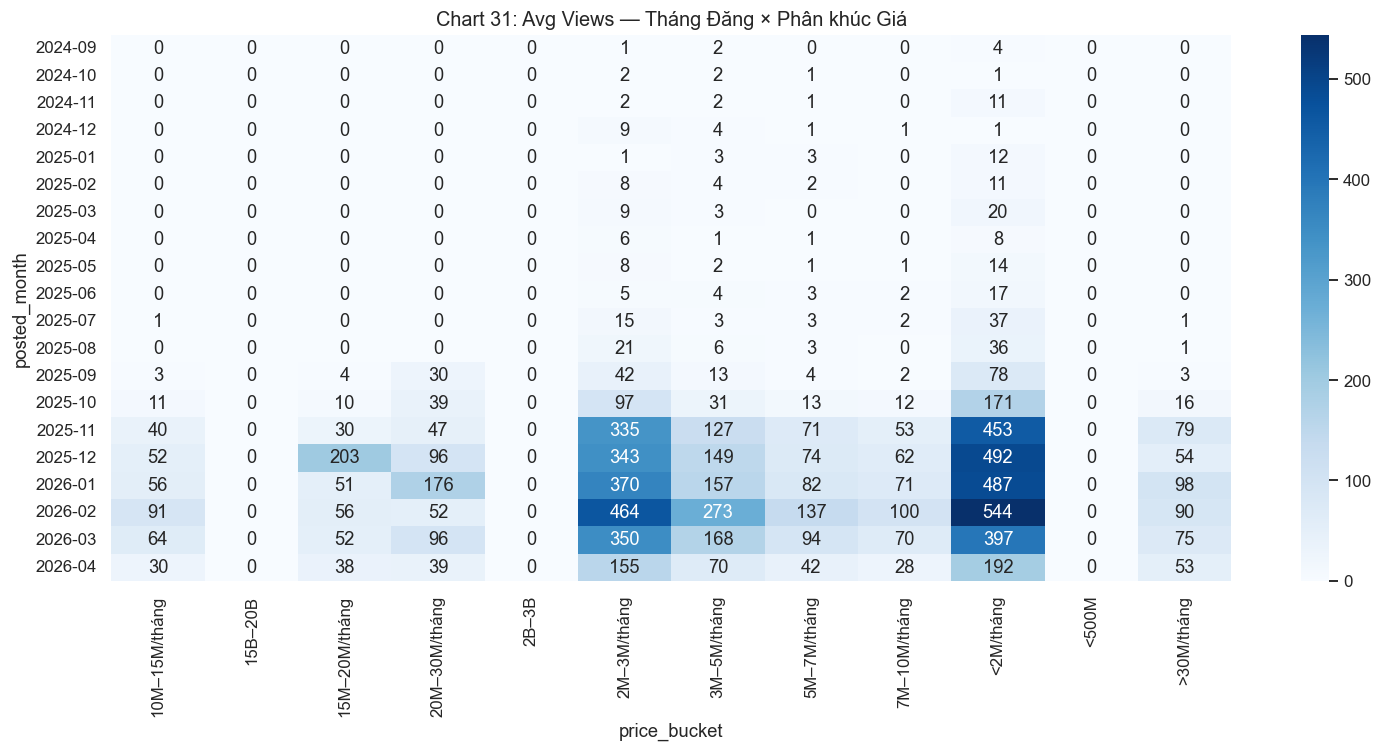

In [45]:
# Chart 31: posted_month × price_bucket → avg views
if 'price_bucket' in df_item.columns:
    hm31 = df_item.groupby(['posted_month','price_bucket'], observed=True)['total_views'].mean().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(14,7))
    sns.heatmap(hm31, annot=True, fmt='.0f', cmap='Blues', ax=ax)
    ax.set_title('Chart 31: Avg Views — Tháng Đăng × Phân khúc Giá', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 31**: Phân tích mùa vụ theo giá. Tháng views cao nhất = mùa cao điểm thuê phòng (6-9 sinh viên, 1-2 sau Tết).

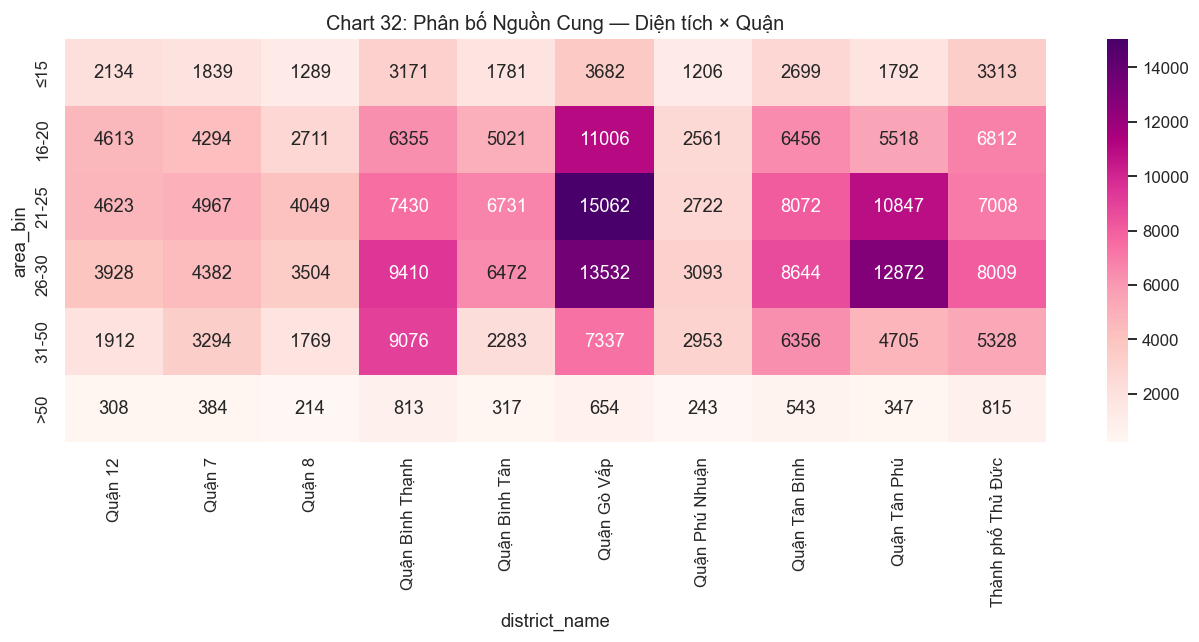

In [46]:
# Chart 32: area_bin × district → listing count
if top10_dist:
    hm32 = df_item[df_item['district_name'].isin(top10_dist)].groupby(
        ['area_bin','district_name'], observed=True)['item_id'].count().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12,6))
    sns.heatmap(hm32, annot=True, fmt='d', cmap='RdPu', ax=ax)
    ax.set_title('Chart 32: Phân bố Nguồn Cung — Diện tích × Quận', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 32**: Mỗi quận có đặc trưng diện tích riêng. ≤15m² = nhà trọ mini. 25-30m² = phòng trọ cao cấp hơn.

---
# Zone 9 — Data Quality & Anomaly Detection (4 charts)

Outlier area >200m²: 842 (0.2%)


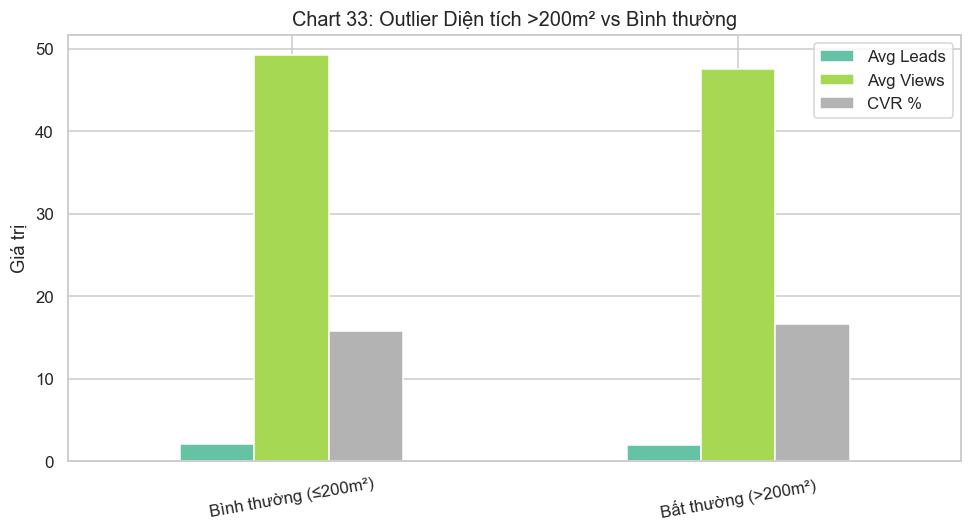

In [47]:
# Chart 33: Outlier area > 200m2
outlier = df_item[df_item['area_sqm'] > 200]
normal  = df_item[df_item['area_sqm'] <= 200]
print(f"Outlier area >200m²: {len(outlier):,} ({len(outlier)/len(df_item)*100:.1f}%)")
cmp33 = pd.DataFrame({
    'Bình thường (≤200m²)': [normal['n_leads'].mean(), normal['total_views'].mean(), normal['has_lead'].mean()*100],
    'Bất thường (>200m²)' : [outlier['n_leads'].mean(), outlier['total_views'].mean(), outlier['has_lead'].mean()*100]
}, index=['Avg Leads','Avg Views','CVR %'])
fig, ax = plt.subplots(figsize=(9,5))
cmp33.T.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Chart 33: Outlier Diện tích >200m² vs Bình thường', fontsize=13)
ax.set_ylabel('Giá trị'); ax.set_xticklabels(cmp33.T.index, rotation=10)
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()


**Chart 33**: Phòng trọ >200m² là bất thường — có thể nhập liệu sai đơn vị. Nếu CVR thấp → data noise cần lọc trước khi modeling.

0 ảnh nhưng có leads: 30
                                                         item_id     district_name price_bucket furnishing_clean  n_leads  total_views
cd8f5f97036cddca278ceb11ca5ffaf80ba64787be9528a8f2d5706e4eebaa72            Quận 8    <2M/tháng             Khác      164       1776.0
4618e762c36e9a306722203d1e5337068913fb26670deceab0f13ee9733d53db Thành phố Thủ Đức  3M–5M/tháng             Khác       33       1376.0
1abf7622f07f53b7091e5f56726bd41281e073e374aeb834b5a35fc039d0c113 Thành phố Thủ Đức  3M–5M/tháng             Khác       27        304.0
792d591d986f36a22e137ad16e79310cec5e6bab902849ef40be92a683f43a09       Quận Cẩm Lệ  2M–3M/tháng             Khác       22        615.0
816dd25b9794055a00ae5bd8d3dac83017ae18bb9366a2274447784f4689e79a   Quận Bình Thạnh  2M–3M/tháng             Khác       21        458.0
fc950cbbf0f3ef03833c31ea3698f375735b629c5afe52eab7bd33e386dda63f            Quận 4    <2M/tháng             Khác       20        473.0
6d8df268acb300dd4b59e945da7c46

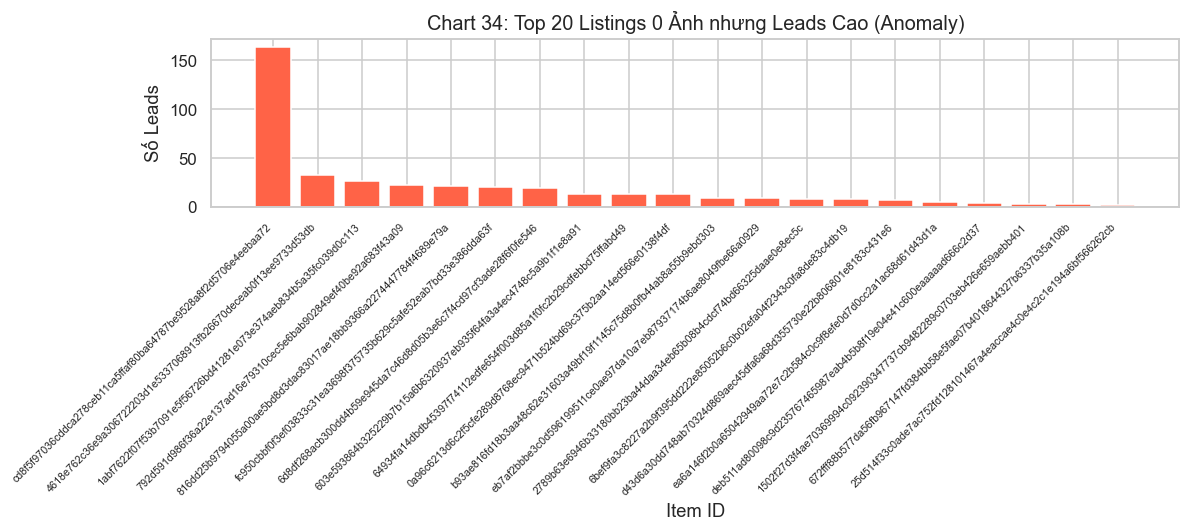

In [48]:
# Chart 34: Anomaly — 0 ảnh nhưng leads cao
an34 = df_item[(df_item['images_count']==0) & (df_item['n_leads']>0)].nlargest(20,'n_leads')
print(f"0 ảnh nhưng có leads: {len(df_item[(df_item['images_count']==0)&(df_item['n_leads']>0)]):,}")
cols34 = [c for c in ['item_id','district_name','price_bucket','furnishing_clean','n_leads','total_views'] if c in df_item.columns]
print(an34[cols34].to_string(index=False))
fig, ax = plt.subplots(figsize=(11,5))
bars34 = ax.bar(range(len(an34)), an34['n_leads'], color='tomato')
ax.set_xticks(range(len(an34)))
ax.set_xticklabels(an34['item_id'].astype(str), rotation=45, ha='right', fontsize=7)
ax.set_title('Chart 34: Top 20 Listings 0 Ảnh nhưng Leads Cao (Anomaly)', fontsize=13)
ax.set_xlabel('Item ID'); ax.set_ylabel('Số Leads')
plt.tight_layout(); plt.show()


**Chart 34**: Listing 0 ảnh vẫn có leads → ảnh không phải yếu tố duy nhất. Có thể do giá rất thấp, vị trí thuận lợi, hoặc seller có reputation tốt.

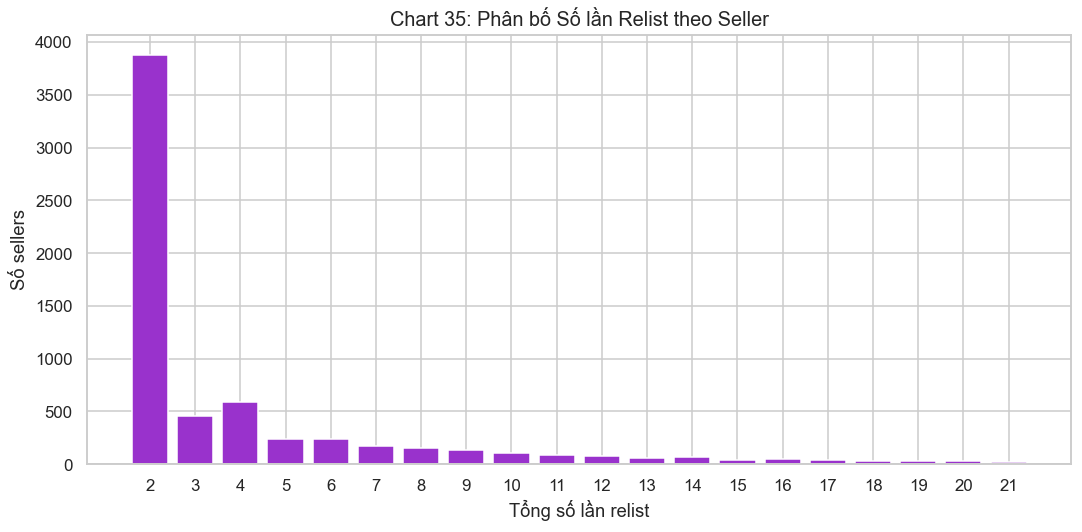

Top 10 sellers relist nhiều nhất:
seller_id
180201831b5daaa4be2c69a1556f411bd2d1a6d1ea8bda303e62406d97a2e9cd    67
0bb3ed53132680e78193bb5e9e2ae0209a9fdf8f9139a2cbe30f1275d029abc9    58
bdec04f466836cac94ba21d7e639ff80b8bd2a8c59717d1bb1b98b9f1f6d20db    54
01244ef6b66585d7ada1a1aee17379821e9ab8168a5846c4821f2b64bb225fc8    50
0243d77508d74afd85ded9974ca3023b7e16a5529351a6b0d8d8ac62cdd0aec9    49
775d3c0109e5b54aede9887ed72e6e2fe77c85c4b135493b4f30a7d459314be9    49
35540d2e15a82a49e79e8011a36b45cc2d3e5cd80dc3149b98f3a28648eca2de    48
547a716d47351891e41ec307e889e3a0c4e38b1f600b94a68ed82f7d7fc3f454    47
9cf3cfaf140f439af4459007bd47dc7d4e8576a34bc552227258089e6b8377c7    47
44c482e0fcd487aa6e8cd52490fadae9664d69dc6f238c8a569054274eb20e28    46
Name: n_list, dtype: int64


In [49]:
# Chart 35: Relist distribution
if 'relist_per_seller' in dir():
    fig, ax = plt.subplots(figsize=(10,5))
    rd = relist_per_seller.value_counts().sort_index().head(20)
    ax.bar(rd.index.astype(str), rd.values, color='darkorchid')
    ax.set_title('Chart 35: Phân bố Số lần Relist theo Seller', fontsize=13)
    ax.set_xlabel('Tổng số lần relist'); ax.set_ylabel('Số sellers')
    plt.tight_layout(); plt.show()
    print("Top 10 sellers relist nhiều nhất:")
    print(relist_per_seller.nlargest(10))
else:
    print("Chạy Chart 28 trước để có biến relist_per_seller")


**Chart 35**: Đa số sellers relist 1-2 lần là bình thường. Relist >10 lần trong 30 ngày → nghi ngờ spam cần kiểm soát.

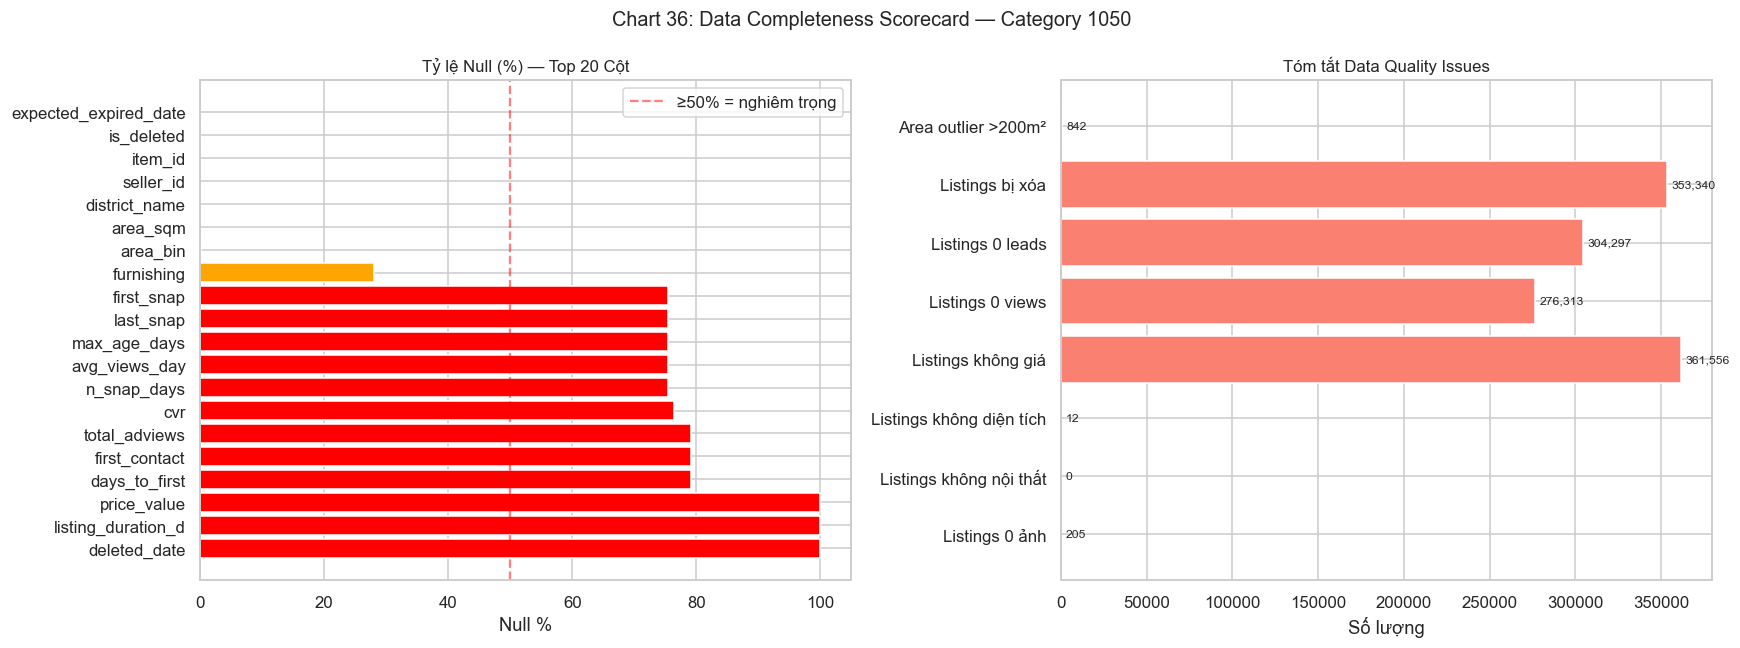


=== DATA QUALITY SUMMARY ===
  Listings 0 ảnh: 205 (0.1%)
  Listings không nội thất: 0 (0.0%)
  Listings không diện tích: 12 (0.0%)
  Listings không giá: 361,556 (100.0%)
  Listings 0 views: 276,313 (76.4%)
  Listings 0 leads: 304,297 (84.2%)
  Listings bị xóa: 353,340 (97.7%)
  Area outlier >200m²: 842 (0.2%)


In [50]:
# Chart 36: Data Completeness Scorecard
null_pct = {col: df_item[col].isna().mean()*100 for col in df_item.columns}
null_df = pd.DataFrame.from_dict(null_pct, orient='index', columns=['null_pct']).sort_values('null_pct', ascending=False)

issues = {
    'Listings 0 ảnh'          : int((df_item['images_count']==0).sum()),
    'Listings không nội thất' : int((df_item['furnishing_clean']=='Không có').sum()),
    'Listings không diện tích': int(df_item['area_sqm'].isna().sum()),
    'Listings không giá'      : int(df_item['price_value'].isna().sum()) if 'price_value' in df_item.columns else 0,
    'Listings 0 views'        : int((df_item['total_views']==0).sum()),
    'Listings 0 leads'        : int((df_item['n_leads']==0).sum()),
    'Listings bị xóa'         : int(df_item['is_deleted'].sum()),
    'Area outlier >200m²'     : int((df_item['area_sqm']>200).sum()),
}

fig, axes = plt.subplots(1,2,figsize=(16,6))
top_null = null_df.head(20)
axes[0].barh(top_null.index, top_null['null_pct'],
             color=['red' if v>50 else 'orange' if v>20 else 'steelblue' for v in top_null['null_pct']])
axes[0].set_title('Tỷ lệ Null (%) — Top 20 Cột', fontsize=11)
axes[0].set_xlabel('Null %')
axes[0].axvline(50, color='red', linestyle='--', alpha=0.5, label='≥50% = nghiêm trọng')
axes[0].legend()

inames = list(issues.keys()); ivals = list(issues.values())
bars36 = axes[1].barh(inames, ivals, color='salmon')
axes[1].set_title('Tóm tắt Data Quality Issues', fontsize=11)
axes[1].set_xlabel('Số lượng')
axes[1].bar_label(bars36, labels=[f'{v:,}' for v in ivals], padding=3, fontsize=8)

fig.suptitle('Chart 36: Data Completeness Scorecard — Category 1050', fontsize=13)
plt.tight_layout(); plt.show()

print("\n=== DATA QUALITY SUMMARY ===")
for k,v in issues.items():
    print(f"  {k}: {v:,} ({v/len(df_item)*100:.1f}%)")


**Chart 36 — Data Completeness Scorecard**: Tổng hợp tất cả vấn đề data quality.
- **Đỏ** (>50% null): Vấn đề nghiêm trọng — không thể dùng làm feature
- **Cam** (20-50% null): Cần imputation hoặc loại bỏ
- **Xanh** (<20% null): Chấp nhận được

Kết quả này là cơ sở để đề xuất cải thiện data pipeline và hướng dẫn seller.

---
# Kết luận EDA v2

## Phương pháp xử lý User ID
| Vấn đề | Giải pháp |
|--------|-----------|
| `user_id` dài 64 ký tự | Rút gọn thành `uid_short` (8 ký tự đầu) cho display |
| `is_login = 'non-login'` | Loại bỏ khỏi phân tích hành vi và contact |
| Non-login không convert | Chỉ giữ login contacts để tính CVR sạch |

## Findings chính (Login-only Analysis)
1. **Login vs Non-login**: CVR của login users cao hơn rõ rệt — đây là nhóm có giá trị
2. **Giá & Diện tích**: Xác định phân khúc CVR cao và price-area mismatch
3. **Chất lượng nội dung**: Tiêu đề 41-60 ký tự và >3 ảnh tương quan với leads cao
4. **Seller**: Agency vs Private có profile rõ ràng khác nhau
5. **Địa lý**: Mỗi quận đặc trưng riêng về nội thất, diện tích, CVR
6. **Hành vi User**: Position bias rõ ràng; dwell time là tín hiệu intent tốt
7. **Vòng đời**: Contact velocity nhanh; listing không contact sau 14 ngày có vấn đề
8. **Data Quality**: Nhiều issues cần xử lý trước modeling

## Bước tiếp theo
- Feature engineering từ cross-dimensional insights
- Model dự đoán leads dựa trên chất lượng listing (login-only labels)
- Phân tích thêm user journey của login users có multiple sessions